In [1]:
!pip install torch-geometric  # Installs PyG with PyTorch compatibility

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.0 MB/s eta 0:00:00a 0:00:01


Device: cuda
Nodes: 314262  |  Feature dim: 310
Graphs built: 5464

 STARTING Bi-HGCL (FULL FINE-TUNING + DECOUPLED PRETRAINING)

  Stage 1: Pretraining (Layer-Wise Decoupled)
 Ep |   L_total |   L_graph |    L_node |  N_pairs |         LR
-----------------------------------------------------------------
  1 |    7.9936 |    4.0413 |    7.9045 |   1474.1 | 5.0529e-05
  2 |    7.5753 |    3.7305 |    7.6895 |   1473.6 | 8.1654e-05
  3 |    6.8046 |    3.1061 |    7.3970 |   1474.8 | 1.3201e-04
  4 |    6.2508 |    2.6963 |    7.1088 |   1471.3 | 1.9939e-04
  5 |    5.7912 |    2.3657 |    6.8509 |   1478.6 | 2.8083e-04
  6 |    5.4193 |    2.0781 |    6.6825 |   1473.6 | 3.7277e-04
  7 |    5.2127 |    1.9508 |    6.5238 |   1475.4 | 4.7116e-04
  8 |    4.9822 |    1.7751 |    6.4144 |   1477.2 | 5.7170e-04
  9 |    4.8907 |    1.7426 |    6.2962 |   1478.5 | 6.6997e-04
 10 |    4.7927 |    1.6752 |    6.2349 |   1476.3 | 7.6166e-04
 11 |    4.6667 |    1.5942 |    6.1449 |   1477.9 | 8

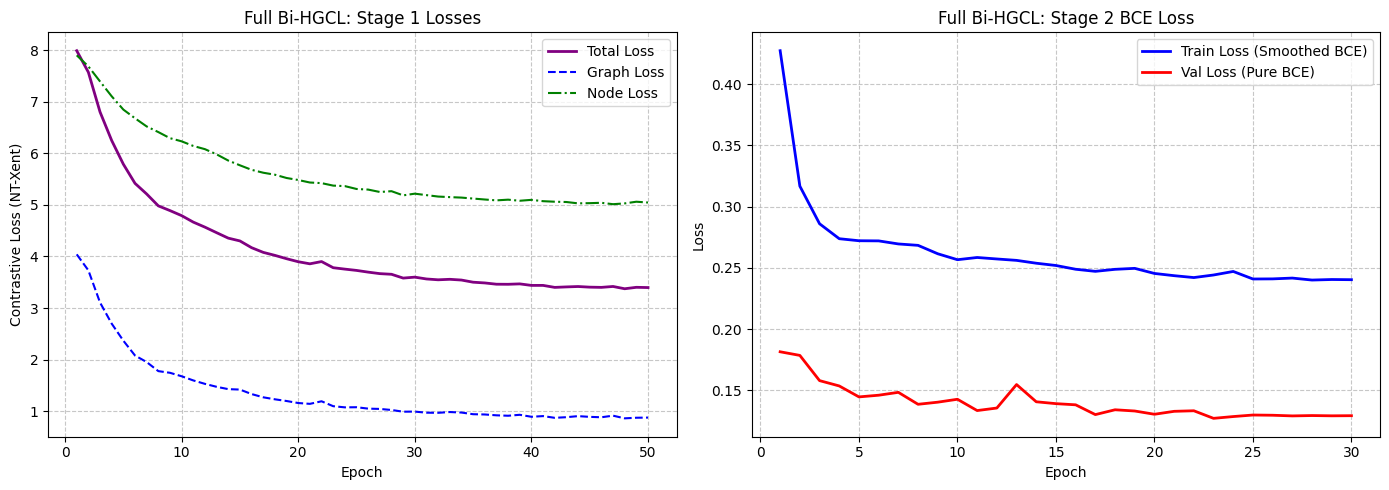

In [12]:
"""
Bi-HGCL v10.0 (Full Fine-Tuning with Single Linear Head)
Layer-Wise Decoupled Contrastive Learning (50 Epochs, 100% Data)
======================================================================
"""

import numpy as np
import scipy.sparse as sp
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import MessagePassing, global_mean_pool
from torch_geometric.utils import softmax, add_self_loops, dropout_edge
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             matthews_corrcoef, roc_auc_score)

# ─────────────────────────────────────────────────────────────────────────────
# 0.  CONFIG
# ─────────────────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# GOSSIPCOP PATH
ROOT         = "/kaggle/input/datasets/ashwinimandlay/gossip-cop-entire-dataset/gossipcop" 
HIDDEN       = 256
HEADS        = 4
GAT_LAYERS   = 2
DROPOUT      = 0.5      

WEIGHT_DECAY = 5e-4     
GRAD_CLIP    = 5.0      

# Regularisation
LABEL_SMOOTH = 0.1
DROPEDGE_P   = 0.1

# Stage 1 - Pretraining 
PRETRAIN_EPOCHS = 50    
PRETRAIN_BATCH  = 32
PRETRAIN_LR     = 1e-3
MASK_RATIO      = 0.1   
DROP_RATIO      = 0.1
TEMPERATURE     = 0.2   
ALPHA           = 0.5     # Balanced for optimal graph structure learning

# Stage 2 - Fine-Tuning 
EPOCHS         = 30
FINETUNE_BATCH = 64
FINETUNE_LR    = 5e-4   # Gentle fine-tuning LR
EARLY_STOP_PAT = 20      

# ─────────────────────────────────────────────────────────────────────────────
# 1.  LOAD DATA
# ─────────────────────────────────────────────────────────────────────────────
graph_labels  = np.load(f"{ROOT}/graph_labels.npy")
node_graph_id = np.load(f"{ROOT}/node_graph_id.npy")
train_idx     = np.load(f"{ROOT}/train_idx.npy")
val_idx       = np.load(f"{ROOT}/val_idx.npy")
test_idx      = np.load(f"{ROOT}/test_idx.npy")
edges         = np.loadtxt(f"{ROOT}/A.txt", delimiter=",", dtype=np.int64)

# ─────────────────────────────────────────────────────────────────────────────
# 2.  FEATURES
# ─────────────────────────────────────────────────────────────────────────────
features = sp.load_npz(f"{ROOT}/new_content_feature.npz").toarray().astype(np.float32)
feat_dim  = features.shape[1]
print(f"Nodes: {features.shape[0]}  |  Feature dim: {feat_dim}")

# ─────────────────────────────────────────────────────────────────────────────
# 3.  BUILD PyG DATA LIST
# ─────────────────────────────────────────────────────────────────────────────
src_arr = edges[:, 0]
dst_arr = edges[:, 1]

n_graphs     = int(node_graph_id.max()) + 1
counts       = np.bincount(node_graph_id, minlength=n_graphs)
graph_starts = np.concatenate([[0], np.cumsum(counts)])

src_gid  = node_graph_id[src_arr]
dst_gid  = node_graph_id[dst_arr]
same     = src_gid == dst_gid
src_arr, dst_arr, src_gid = src_arr[same], dst_arr[same], src_gid[same]

order   = np.argsort(src_gid, kind="stable")
src_arr = src_arr[order]; dst_arr = dst_arr[order]; src_gid = src_gid[order]
edge_split = np.searchsorted(src_gid, np.arange(n_graphs + 1))

data_list = []
for gid in range(n_graphs):
    s = graph_starts[gid]; e = graph_starts[gid + 1]
    if e <= s: continue
    node_ids = np.arange(s, e)
    local    = {g: l for l, g in enumerate(node_ids)}
    x        = torch.tensor(features[node_ids], dtype=torch.float32)

    es, ee = edge_split[gid], edge_split[gid + 1]
    if es < ee:
        sl = np.array([local.get(n, -1) for n in src_arr[es:ee]])
        dl = np.array([local.get(n, -1) for n in dst_arr[es:ee]])
        v  = (sl >= 0) & (dl >= 0)
        sl = sl[v].astype(np.int64); dl = dl[v].astype(np.int64)
        edge_index = torch.tensor(np.stack([sl, dl]), dtype=torch.long)
    else:
        n          = len(node_ids)
        edge_index = torch.stack([torch.arange(n), torch.arange(n)])

    edge_index, _ = add_self_loops(edge_index, num_nodes=len(node_ids))

    y               = torch.tensor([int(graph_labels[gid])], dtype=torch.long)
    d               = Data(x=x, edge_index=edge_index, y=y)
    d.is_content    = torch.zeros(len(node_ids), dtype=torch.bool)
    d.is_content[0] = True
    data_list.append(d)

print(f"Graphs built: {len(data_list)}")

pretrain_loader = DataLoader([data_list[i] for i in train_idx], batch_size=PRETRAIN_BATCH, shuffle=True)
train_loader    = DataLoader([data_list[i] for i in train_idx], batch_size=FINETUNE_BATCH, shuffle=True)
val_loader      = DataLoader([data_list[i] for i in val_idx],   batch_size=128,   shuffle=False)
test_loader     = DataLoader([data_list[i] for i in test_idx],  batch_size=128,   shuffle=False)

# ─────────────────────────────────────────────────────────────────────────────
# 4.  GRAPH AUGMENTOR
# ─────────────────────────────────────────────────────────────────────────────
class GraphAugmentor:
    def __init__(self, mask_ratio=0.1, drop_ratio=0.1):
        self.mask_ratio = mask_ratio
        self.drop_ratio = drop_ratio

    @torch.no_grad()
    def augment(self, data):
        x          = data.x.clone()
        edge_index = data.edge_index.clone()
        is_content = data.is_content.clone()
        batch      = (data.batch.clone() if data.batch is not None
                      else torch.zeros(x.size(0), dtype=torch.long, device=x.device))
        N, dev = x.size(0), x.device

        x = x * torch.bernoulli(torch.full((N, x.size(1)), 1.0 - self.mask_ratio, device=dev)).float()

        user_keep    = torch.bernoulli(torch.full((N,), 1.0 - self.drop_ratio, device=dev)).bool()
        keep         = is_content | user_keep
        keep_indices = keep.nonzero(as_tuple=True)[0]

        if keep.all():
            return (Data(x=x, edge_index=edge_index, y=data.y, is_content=is_content, batch=batch), keep_indices)

        if keep.sum() == 0:
            keep[0]      = True
            keep_indices = torch.tensor([0], device=dev)

        new_idx       = torch.full((N,), -1, dtype=torch.long, device=dev)
        new_idx[keep] = torch.arange(keep.sum(), device=dev)
        src, dst      = edge_index
        edge_keep     = keep[src] & keep[dst]

        aug = Data(
            x          = x[keep],
            edge_index = torch.stack([new_idx[src[edge_keep]], new_idx[dst[edge_keep]]]),
            y          = data.y,
            is_content = is_content[keep],
            batch      = batch[keep],
        )
        return aug, keep_indices

augmentor = GraphAugmentor(mask_ratio=MASK_RATIO, drop_ratio=DROP_RATIO)

def align_node_pairs(h1, keep1, h2, keep2):
    mask1 = torch.isin(keep1, keep2)
    mask2 = torch.isin(keep2, keep1)
    if mask1.sum() == 0: return None, None
    sort1 = torch.argsort(keep1[mask1])
    sort2 = torch.argsort(keep2[mask2])
    return h1[mask1][sort1], h2[mask2][sort2]

# ─────────────────────────────────────────────────────────────────────────────
# 5.  MODEL COMPONENTS
# ─────────────────────────────────────────────────────────────────────────────
class SemanticEncoder(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.5):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(in_dim),
            nn.Linear(in_dim, out_dim * 2),
            nn.GELU(), nn.Dropout(dropout),
            nn.Linear(out_dim * 2, out_dim),
        )
    def forward(self, x): return self.net(x)

class MetadataProjector(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.5):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(in_dim),
            nn.Linear(in_dim, out_dim * 2),
            nn.GELU(), nn.Dropout(dropout),
            nn.Linear(out_dim * 2, out_dim),
        )
    def forward(self, x): return self.net(x)

class GATConv(MessagePassing):
    def __init__(self, in_dim, out_dim, dropout=0.5):
        super().__init__(aggr="mean") # Stabilizes learning for dense social graphs
        self.W    = nn.Linear(in_dim, out_dim, bias=False)
        self.a    = nn.Linear(2 * out_dim, 1, bias=False)
        self.drop = nn.Dropout(dropout)
        nn.init.xavier_uniform_(self.W.weight)

    def forward(self, h, edge_index):
        return self.propagate(edge_index, Wh=self.W(h), size=(h.size(0), h.size(0)))

    def message(self, Wh_i, Wh_j, index):
        e = F.leaky_relu(self.a(torch.cat([Wh_i, Wh_j], dim=-1)), 0.2)
        return Wh_j * self.drop(softmax(e, index))

class MultiHeadGAT(nn.Module):
    def __init__(self, in_dim, out_dim, heads=4, dropout=0.5):
        super().__init__()
        assert out_dim % heads == 0
        d          = out_dim // heads
        self.heads = nn.ModuleList([GATConv(in_dim, d, dropout) for _ in range(heads)])
        self.ln    = nn.LayerNorm(out_dim)
        self.res   = (nn.Linear(in_dim, out_dim, bias=False) if in_dim != out_dim else nn.Identity())

    def forward(self, h, edge_index):
        out = torch.cat([head(h, edge_index) for head in self.heads], dim=-1)
        return self.ln(F.elu(out) + self.res(h))

class NTXentLoss(nn.Module):
    def __init__(self, temperature=0.2):
        super().__init__()
        self.tau = temperature

    def forward(self, z1, z2):
        N = z1.size(0)
        if N < 2: return z1.sum() * 0.0
        z      = F.normalize(torch.cat([z1, z2], dim=0), dim=-1)
        sim    = torch.mm(z, z.T) / self.tau
        labels = torch.cat([torch.arange(N, 2*N, device=z.device),
                            torch.arange(0, N,   device=z.device)])
        sim    = sim.masked_fill(torch.eye(2*N, dtype=torch.bool, device=z.device), -1e9)
        return F.cross_entropy(sim, labels)

# ─────────────────────────────────────────────────────────────────────────────
# 6.  BI-HGCL MODEL
# ─────────────────────────────────────────────────────────────────────────────
class BiHGCL(nn.Module):
    def __init__(self, feat_dim, hidden=256, heads=4, gat_layers=2, dropout=0.5, temperature=0.2):
        super().__init__()
        self.sem_enc    = SemanticEncoder(feat_dim, hidden, dropout)
        self.meta_prj   = MetadataProjector(feat_dim, hidden, dropout)
        self.gat        = nn.ModuleList([MultiHeadGAT(hidden, hidden, heads, dropout) for _ in range(gat_layers)])
        self.ntxent     = NTXentLoss(temperature)
        
        # Robust 3-Layer Projection Heads for Contrastive Learning
        self.node_proj = nn.Sequential(
            nn.Linear(hidden, hidden), nn.GELU(),
            nn.Linear(hidden, hidden), nn.GELU(),
            nn.Linear(hidden, hidden // 2)
        )
        self.graph_proj = nn.Sequential(
            nn.Linear(hidden, hidden), nn.GELU(),
            nn.Linear(hidden, hidden), nn.GELU(),
            nn.Linear(hidden, hidden // 2)
        )
        
        # Single Linear Classifier Layer (No MLP untangling)
        self.classifier = nn.Linear(hidden, 1)

    def _batch(self, data):
        return (data.batch.to(device) if data.batch is not None
                else torch.zeros(data.x.size(0), dtype=torch.long, device=device))

    def encode_nodes(self, data, dropedge_p=0.0):
        x          = data.x.to(device)
        edge_index = data.edge_index.to(device)
        is_content = data.is_content.to(device)
        batch      = self._batch(data)

        if dropedge_p > 0.0 and self.training:
            edge_index, _ = dropout_edge(edge_index, p=dropedge_p, training=True)

        h_content = self.sem_enc(x)
        h_user    = self.meta_prj(x)
        mask      = is_content.unsqueeze(-1).expand_as(h_user)
        h         = torch.where(mask, h_content, h_user)

        h_mid = None
        for i, layer in enumerate(self.gat):
            h = layer(h, edge_index)
            if i == 0:
                h_mid = h 

        Z = global_mean_pool(h, batch)
        return h_mid, h, Z, batch

    def forward(self, data, dropedge_p=0.0):
        _, _, Z, _ = self.encode_nodes(data, dropedge_p)
        logits     = self.classifier(Z).squeeze(-1)
        return logits, Z

# ─────────────────────────────────────────────────────────────────────────────
# 7.  STAGE 1 — PRETRAINING
# ─────────────────────────────────────────────────────────────────────────────
def pretrain(model, loader, epochs=PRETRAIN_EPOCHS, lr=PRETRAIN_LR, alpha=ALPHA,
             use_graph_loss=True, use_node_loss=True):
    
    history = {'total_loss': [], 'graph_loss': [], 'node_loss': []}
    
    if not use_graph_loss and not use_node_loss:
        return history 

    enc_params = (list(model.sem_enc.parameters())  +
                  list(model.meta_prj.parameters()) +
                  list(model.gat.parameters()) +
                  list(model.node_proj.parameters()) +
                  list(model.graph_proj.parameters()))
                  
    opt   = torch.optim.Adam(enc_params, lr=lr, weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=lr, steps_per_epoch=len(loader), epochs=epochs, pct_start=0.3)

    print("\n" + "=" * 70)
    print("  Stage 1: Pretraining (Layer-Wise Decoupled)")
    print(f"{'Ep':>3} | {'L_total':>9} | {'L_graph':>9} | {'L_node':>9} | {'N_pairs':>8} | {'LR':>10}")
    print("-" * 65)

    model.train()
    for epoch in range(1, epochs + 1):
        t_total = t_graph = t_node = 0.0
        n_batches = n_pairs_total = 0

        for data in loader:
            data = data.to(device)
            v1, keep1 = augmentor.augment(data)
            v2, keep2 = augmentor.augment(data)

            h1_mid, _, z1, _ = model.encode_nodes(v1, dropedge_p=0.0)
            h2_mid, _, z2, _ = model.encode_nodes(v2, dropedge_p=0.0)

            loss = torch.tensor(0.0, device=device)
            l_graph_val = 0.0
            l_node_val = 0.0

            if use_graph_loss:
                p_z1 = model.graph_proj(z1)
                p_z2 = model.graph_proj(z2)
                l_graph = model.ntxent(p_z1, p_z2)
                loss = loss + l_graph
                l_graph_val = l_graph.item()

            if use_node_loss:
                batch_ids = data.batch if data.batch is not None else torch.zeros(data.x.size(0), dtype=torch.long, device=device)
                v1_batch  = v1.batch if v1.batch is not None else torch.zeros(v1.x.size(0), dtype=torch.long, device=device)
                v2_batch  = v2.batch if v2.batch is not None else torch.zeros(v2.x.size(0), dtype=torch.long, device=device)

                all_va, all_vb = [], []
                off1 = off2 = 0
                
                for gid in range(int(batch_ids.max().item()) + 1):
                    om   = (batch_ids == gid)
                    os   = om.nonzero(as_tuple=True)[0][0].item()
                    oe   = os + om.sum().item()
                    n1   = (v1_batch == gid).sum().item()
                    n2   = (v2_batch == gid).sum().item()
                    
                    h1g  = h1_mid[off1:off1+n1]
                    h2g  = h2_mid[off2:off2+n2]
                    k1g  = keep1[(keep1 >= os) & (keep1 < oe)] - os
                    k2g  = keep2[(keep2 >= os) & (keep2 < oe)] - os
                    
                    va, vb = align_node_pairs(h1g, k1g, h2g, k2g)
                    if va is not None and va.size(0) > 0:
                        all_va.append(va)
                        all_vb.append(vb)
                        n_pairs_total += va.size(0)
                    off1 += n1; off2 += n2

                if all_va:
                    batch_va = torch.cat(all_va, dim=0)
                    batch_vb = torch.cat(all_vb, dim=0)
                    if batch_va.size(0) >= 2:
                        p_va = model.node_proj(batch_va)
                        p_vb = model.node_proj(batch_vb)
                        l_node = model.ntxent(p_va, p_vb)
                        
                        loss = loss + alpha * l_node
                        l_node_val = l_node.item()

            if loss.item() > 0:
                opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(enc_params, GRAD_CLIP)
                opt.step()
                sched.step() 

            t_total += loss.item()
            t_graph += l_graph_val
            t_node  += l_node_val
            n_batches += 1

        avg_total = t_total / n_batches if n_batches > 0 else 0
        avg_graph = t_graph / n_batches if n_batches > 0 else 0
        avg_node  = t_node / n_batches if n_batches > 0 else 0
        
        history['total_loss'].append(avg_total)
        history['graph_loss'].append(avg_graph)
        history['node_loss'].append(avg_node)

        print(f"{epoch:>3} | {avg_total:>9.4f} | {avg_graph:>9.4f} | "
              f"{avg_node:>9.4f} | {n_pairs_total/n_batches:>8.1f} | "
              f"{opt.param_groups[0]['lr']:.4e}")

    return history

# ─────────────────────────────────────────────────────────────────────────────
# 8.  EVALUATION 
# ─────────────────────────────────────────────────────────────────────────────
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    total_loss = 0.0
    
    for data in loader:
        data      = data.to(device)
        labels    = data.y.squeeze()
        logits, _ = model(data, dropedge_p=0.0)
        
        loss = F.binary_cross_entropy_with_logits(logits.float(), labels.float().to(device))
        total_loss += loss.item()

        probs     = torch.sigmoid(logits).cpu().float().numpy()
        preds     = (probs >= 0.5).astype(int)
        all_probs.extend(probs.tolist())
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.cpu().numpy().tolist())

    val_loss = total_loss / len(loader)
    acc  = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, zero_division=0)
    rec  = recall_score(all_labels, all_preds, zero_division=0)
    f1   = f1_score(all_labels, all_preds, zero_division=0)
    mcc  = matthews_corrcoef(all_labels, all_preds)
    try:    auc = roc_auc_score(all_labels, all_probs)
    except: auc = float("nan")
    
    return dict(loss=val_loss, acc=acc, prec=prec, rec=rec, f1=f1, mcc=mcc, auc=auc)

# ─────────────────────────────────────────────────────────────────────────────
# 9.  STAGE 2 — FINE-TUNING (All parameters train) + TRACK ARRAYS
# ─────────────────────────────────────────────────────────────────────────────
def train_model(model, epochs=EPOCHS, dropedge_p=DROPEDGE_P,
                label_smooth=LABEL_SMOOTH, early_stop_pat=EARLY_STOP_PAT):
    
    # Notice: model.parameters() means EVERYTHING is fine-tuning (Not linear probing)
    optimizer = torch.optim.Adam(model.parameters(), lr=FINETUNE_LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

    best_f1, best_state, best_ep = 0.0, None, 0
    no_improve = 0
    
    # Tracking arrays for all metrics
    history = {
        'train_loss': [], 'val_loss': [], 
        'val_acc': [], 'val_prec': [], 
        'val_rec': [], 'val_f1': [], 'val_auc': []
    }

    print("\n" + "=" * 70)
    print("  Stage 2: Regularised Pure BCE Fine-Tuning")
    print(f"{'Ep':>3} | {'Loss':>7} | {'TrAcc':>6} | {'ValAcc':>6} | {'ValF1':>6} | {'AUC':>6} | {'LR':>8}")
    print("-" * 70)

    for epoch in range(1, epochs + 1):
        model.train()
        tot = 0.0
        tr_preds, tr_labs = [], []

        for data in train_loader:
            data   = data.to(device)
            labels = data.y.squeeze().to(device)
            optimizer.zero_grad()
            logits, _ = model(data, dropedge_p=dropedge_p)

            smooth = labels.float() * (1 - label_smooth) + 0.5 * label_smooth
            loss   = F.binary_cross_entropy_with_logits(logits.float(), smooth)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()

            tot += loss.item()
            tr_preds += ((torch.sigmoid(logits).detach().cpu().numpy() >= 0.5).astype(int).tolist())
            tr_labs  += labels.cpu().numpy().tolist()

        train_loss = tot / len(train_loader)
        tacc       = accuracy_score(tr_labs, tr_preds)
        
        vm         = evaluate(model, val_loader)
        val_loss   = vm['loss']
        val_f1     = vm['f1']
        
        # Save epoch metrics to arrays
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(round(vm['acc'], 4))
        history['val_prec'].append(round(vm['prec'], 4))
        history['val_rec'].append(round(vm['rec'], 4))
        history['val_f1'].append(round(vm['f1'], 4))
        history['val_auc'].append(round(vm['auc'], 4))

        scheduler.step()
        cur_lr = optimizer.param_groups[0]["lr"]

        if val_f1 > best_f1:
            best_f1, best_ep = val_f1, epoch
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve  = 0
        else:
            no_improve += 1

        print(f"{epoch:>3} | {train_loss:>7.4f} | {tacc*100:>5.1f}% | "
              f"{vm['acc']*100:>5.1f}% | {val_f1*100:>5.1f}% | "
              f"{vm['auc']:>6.4f} | {cur_lr:.2e}"
              + (" ←" if no_improve == 0 else ""))

        if no_improve >= early_stop_pat:
            print(f"  Early stopping at epoch {epoch}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history

# ─────────────────────────────────────────────────────────────────────────────
# 10. PLOT LEARNING CURVES
# ─────────────────────────────────────────────────────────────────────────────
def plot_learning_curves(hist_stage1, hist_stage2, title_prefix):
    plt.figure(figsize=(14, 5))
    
    plt.subplot(1, 2, 1)
    if hist_stage1 and len(hist_stage1['total_loss']) > 0:
        epochs_s1 = range(1, len(hist_stage1['total_loss']) + 1)
        plt.plot(epochs_s1, hist_stage1['total_loss'], label='Total Loss', color='purple', linewidth=2)
        
        if sum(hist_stage1['graph_loss']) > 0:
            plt.plot(epochs_s1, hist_stage1['graph_loss'], label='Graph Loss', color='blue', linestyle='--')
        if sum(hist_stage1['node_loss']) > 0:
            plt.plot(epochs_s1, hist_stage1['node_loss'], label='Node Loss', color='green', linestyle='-.')
            
        plt.title(f"{title_prefix}: Stage 1 Losses")
        plt.xlabel("Epoch")
        plt.ylabel("Contrastive Loss (NT-Xent)")
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
    else:
        plt.title(f"{title_prefix}: Stage 1 Skipped")
        plt.axis('off')
        plt.text(0.5, 0.5, 'Stage 1 Ablated', horizontalalignment='center', verticalalignment='center', fontsize=14)

    plt.subplot(1, 2, 2)
    epochs_s2 = range(1, len(hist_stage2['train_loss']) + 1)
    plt.plot(epochs_s2, hist_stage2['train_loss'], label='Train Loss (Smoothed BCE)', color='blue', linewidth=2)
    plt.plot(epochs_s2, hist_stage2['val_loss'], label='Val Loss (Pure BCE)', color='red', linewidth=2)
    plt.title(f"{title_prefix}: Stage 2 BCE Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# 11.  EXECUTION & ARRAY EXTRACTION
# ─────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    
    print("\n" + "="*85)
    print(" STARTING Bi-HGCL (FULL FINE-TUNING + DECOUPLED PRETRAINING)")
    print("="*85)

    # Initialize model
    model = BiHGCL(feat_dim, HIDDEN, HEADS, GAT_LAYERS, DROPOUT, TEMPERATURE).to(device)
    
    # Run Stage 1 Pretraining
    hist1 = pretrain(model, pretrain_loader, use_graph_loss=True, use_node_loss=True)

    # Run Stage 2 Fine-Tuning
    model, hist2 = train_model(model)
    
    # Evaluate on Unseen Test Set
    tm = evaluate(model, test_loader)
    
    print("\n" + "="*85)
    print(" 📊 EPOCH-BY-EPOCH VALIDATION ARRAYS (For Plotting/Analysis)")
    print("="*85)
    print(f"val_accuracy_array  = {hist2['val_acc']}")
    print(f"val_precision_array = {hist2['val_prec']}")
    print(f"val_recall_array    = {hist2['val_rec']}")
    print(f"val_f1_score_array  = {hist2['val_f1']}")
    print(f"val_auc_array       = {hist2['val_auc']}")
    print(f"train_loss_array    = {[round(x, 4) for x in hist2['train_loss']]}")
    print(f"val_loss_array      = {[round(x, 4) for x in hist2['val_loss']]}")

    print("\n" + "="*85)
    print(" 🎯 FINAL TEST METRICS ARRAY")
    print(" Format: [Accuracy, Precision, Recall, F1-Score, AUC]")
    print("="*85)
    final_test_array = [
        round(tm['acc'], 4), 
        round(tm['prec'], 4), 
        round(tm['rec'], 4), 
        round(tm['f1'], 4), 
        round(tm['auc'], 4)
    ]
    print(f"final_test_array = {final_test_array}")
    print("="*85 + "\n")

    # Plot final curves
    plot_learning_curves(hist1, hist2, title_prefix="Full Bi-HGCL")

Device: cuda
Nodes: 314262  |  Feature dim: 310
Graphs built: 5464

 STARTING Bi-HGCL (ABLATION: WITHOUT NODE LOSS)

  Stage 1: Pretraining (Graph Loss: True, Node Loss: False)
 Ep |   L_total |   L_graph |    L_node |  N_pairs |         LR
-----------------------------------------------------------------
  1 |    5.4385 |    5.4385 |    0.0000 |      0.0 | 6.9668e-05
  2 |    5.3561 |    5.3561 |    0.0000 |      0.0 | 1.5501e-04
  3 |    4.9591 |    4.9591 |    0.0000 |      0.0 | 2.8546e-04
  4 |    4.4104 |    4.4104 |    0.0000 |      0.0 | 4.4491e-04
  5 |    3.9357 |    3.9357 |    0.0000 |      0.0 | 6.1364e-04
  6 |    3.6562 |    3.6562 |    0.0000 |      0.0 | 7.7080e-04
  7 |    3.4676 |    3.4676 |    0.0000 |      0.0 | 8.9695e-04
  8 |    3.3381 |    3.3381 |    0.0000 |      0.0 | 9.7651e-04
  9 |    3.2446 |    3.2446 |    0.0000 |      0.0 | 9.9993e-04
 10 |    3.1896 |    3.1896 |    0.0000 |      0.0 | 9.9311e-04
 11 |    3.1127 |    3.1127 |    0.0000 |      0.0 | 

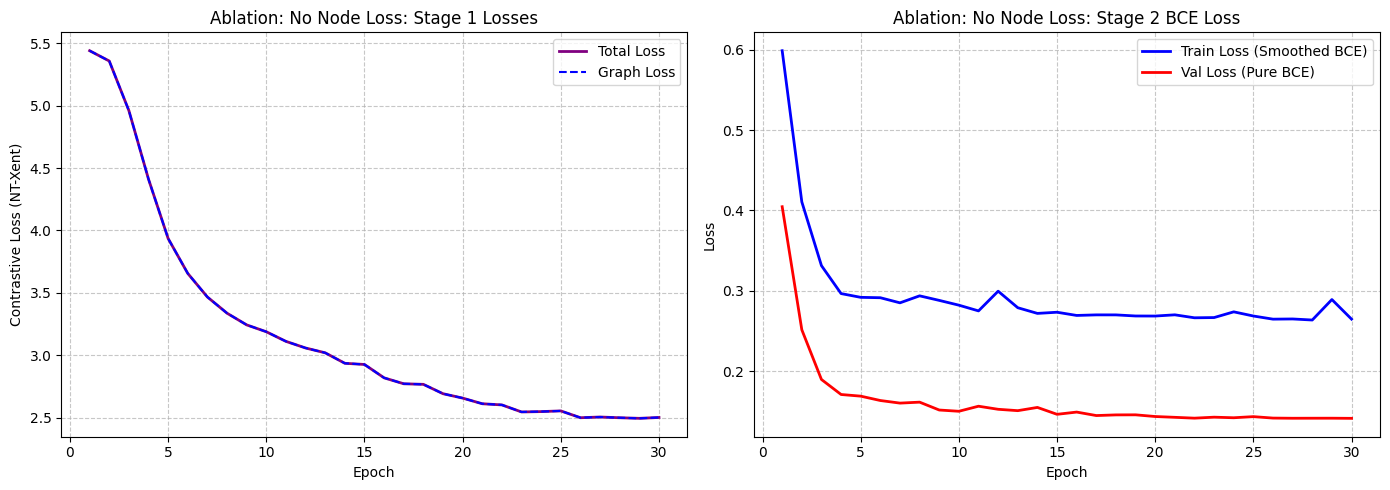

In [21]:
"""
Bi-HGCL v10.0 (Ablation: Without Node Loss)
Full Fine-Tuning with Single Linear Head
======================================================================
"""

import numpy as np
import scipy.sparse as sp
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import MessagePassing, global_mean_pool
from torch_geometric.utils import softmax, add_self_loops, dropout_edge
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             matthews_corrcoef, roc_auc_score)

# ─────────────────────────────────────────────────────────────────────────────
# 0.  CONFIG
# ─────────────────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# GOSSIPCOP PATH
ROOT         = "/kaggle/input/datasets/ashwinimandlay/gossip-cop-entire-dataset/gossipcop" 
HIDDEN       = 256
HEADS        = 4
GAT_LAYERS   = 2
DROPOUT      = 0.5      

WEIGHT_DECAY = 5e-4     
GRAD_CLIP    = 5.0      

# Regularisation
LABEL_SMOOTH = 0.1
DROPEDGE_P   = 0.1

# Stage 1 - Pretraining 
PRETRAIN_EPOCHS = 30    
PRETRAIN_BATCH  = 128
PRETRAIN_LR     = 1e-3
MASK_RATIO      = 0.1   
DROP_RATIO      = 0.1
TEMPERATURE     = 0.2   
ALPHA           = 0.5     # Balanced for optimal graph structure learning

# Stage 2 - Fine-Tuning 
EPOCHS         = 30
FINETUNE_BATCH = 64
FINETUNE_LR    = 1e-4   # Gentle fine-tuning LR
EARLY_STOP_PAT = 20      

# ─────────────────────────────────────────────────────────────────────────────
# 1.  LOAD DATA
# ─────────────────────────────────────────────────────────────────────────────
graph_labels  = np.load(f"{ROOT}/graph_labels.npy")
node_graph_id = np.load(f"{ROOT}/node_graph_id.npy")
train_idx     = np.load(f"{ROOT}/train_idx.npy")
val_idx       = np.load(f"{ROOT}/val_idx.npy")
test_idx      = np.load(f"{ROOT}/test_idx.npy")
edges         = np.loadtxt(f"{ROOT}/A.txt", delimiter=",", dtype=np.int64)

# ─────────────────────────────────────────────────────────────────────────────
# 2.  FEATURES
# ─────────────────────────────────────────────────────────────────────────────
features = sp.load_npz(f"{ROOT}/new_content_feature.npz").toarray().astype(np.float32)
feat_dim  = features.shape[1]
print(f"Nodes: {features.shape[0]}  |  Feature dim: {feat_dim}")

# ─────────────────────────────────────────────────────────────────────────────
# 3.  BUILD PyG DATA LIST
# ─────────────────────────────────────────────────────────────────────────────
src_arr = edges[:, 0]
dst_arr = edges[:, 1]

n_graphs     = int(node_graph_id.max()) + 1
counts       = np.bincount(node_graph_id, minlength=n_graphs)
graph_starts = np.concatenate([[0], np.cumsum(counts)])

src_gid  = node_graph_id[src_arr]
dst_gid  = node_graph_id[dst_arr]
same     = src_gid == dst_gid
src_arr, dst_arr, src_gid = src_arr[same], dst_arr[same], src_gid[same]

order   = np.argsort(src_gid, kind="stable")
src_arr = src_arr[order]; dst_arr = dst_arr[order]; src_gid = src_gid[order]
edge_split = np.searchsorted(src_gid, np.arange(n_graphs + 1))

data_list = []
for gid in range(n_graphs):
    s = graph_starts[gid]; e = graph_starts[gid + 1]
    if e <= s: continue
    node_ids = np.arange(s, e)
    local    = {g: l for l, g in enumerate(node_ids)}
    x        = torch.tensor(features[node_ids], dtype=torch.float32)

    es, ee = edge_split[gid], edge_split[gid + 1]
    if es < ee:
        sl = np.array([local.get(n, -1) for n in src_arr[es:ee]])
        dl = np.array([local.get(n, -1) for n in dst_arr[es:ee]])
        v  = (sl >= 0) & (dl >= 0)
        sl = sl[v].astype(np.int64); dl = dl[v].astype(np.int64)
        edge_index = torch.tensor(np.stack([sl, dl]), dtype=torch.long)
    else:
        n          = len(node_ids)
        edge_index = torch.stack([torch.arange(n), torch.arange(n)])

    edge_index, _ = add_self_loops(edge_index, num_nodes=len(node_ids))

    y               = torch.tensor([int(graph_labels[gid])], dtype=torch.long)
    d               = Data(x=x, edge_index=edge_index, y=y)
    d.is_content    = torch.zeros(len(node_ids), dtype=torch.bool)
    d.is_content[0] = True
    data_list.append(d)

print(f"Graphs built: {len(data_list)}")

pretrain_loader = DataLoader([data_list[i] for i in train_idx], batch_size=PRETRAIN_BATCH, shuffle=True)
train_loader    = DataLoader([data_list[i] for i in train_idx], batch_size=FINETUNE_BATCH, shuffle=True)
val_loader      = DataLoader([data_list[i] for i in val_idx],   batch_size=128,   shuffle=False)
test_loader     = DataLoader([data_list[i] for i in test_idx],  batch_size=128,   shuffle=False)

# ─────────────────────────────────────────────────────────────────────────────
# 4.  GRAPH AUGMENTOR
# ─────────────────────────────────────────────────────────────────────────────
class GraphAugmentor:
    def __init__(self, mask_ratio=0.1, drop_ratio=0.1):
        self.mask_ratio = mask_ratio
        self.drop_ratio = drop_ratio

    @torch.no_grad()
    def augment(self, data):
        x          = data.x.clone()
        edge_index = data.edge_index.clone()
        is_content = data.is_content.clone()
        batch      = (data.batch.clone() if data.batch is not None
                      else torch.zeros(x.size(0), dtype=torch.long, device=x.device))
        N, dev = x.size(0), x.device

        x = x * torch.bernoulli(torch.full((N, x.size(1)), 1.0 - self.mask_ratio, device=dev)).float()

        user_keep    = torch.bernoulli(torch.full((N,), 1.0 - self.drop_ratio, device=dev)).bool()
        keep         = is_content | user_keep
        keep_indices = keep.nonzero(as_tuple=True)[0]

        if keep.all():
            return (Data(x=x, edge_index=edge_index, y=data.y, is_content=is_content, batch=batch), keep_indices)

        if keep.sum() == 0:
            keep[0]      = True
            keep_indices = torch.tensor([0], device=dev)

        new_idx       = torch.full((N,), -1, dtype=torch.long, device=dev)
        new_idx[keep] = torch.arange(keep.sum(), device=dev)
        src, dst      = edge_index
        edge_keep     = keep[src] & keep[dst]

        aug = Data(
            x          = x[keep],
            edge_index = torch.stack([new_idx[src[edge_keep]], new_idx[dst[edge_keep]]]),
            y          = data.y,
            is_content = is_content[keep],
            batch      = batch[keep],
        )
        return aug, keep_indices

augmentor = GraphAugmentor(mask_ratio=MASK_RATIO, drop_ratio=DROP_RATIO)

def align_node_pairs(h1, keep1, h2, keep2):
    mask1 = torch.isin(keep1, keep2)
    mask2 = torch.isin(keep2, keep1)
    if mask1.sum() == 0: return None, None
    sort1 = torch.argsort(keep1[mask1])
    sort2 = torch.argsort(keep2[mask2])
    return h1[mask1][sort1], h2[mask2][sort2]

# ─────────────────────────────────────────────────────────────────────────────
# 5.  MODEL COMPONENTS
# ─────────────────────────────────────────────────────────────────────────────
class SemanticEncoder(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.5):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(in_dim),
            nn.Linear(in_dim, out_dim * 2),
            nn.GELU(), nn.Dropout(dropout),
            nn.Linear(out_dim * 2, out_dim),
        )
    def forward(self, x): return self.net(x)

class MetadataProjector(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.5):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(in_dim),
            nn.Linear(in_dim, out_dim * 2),
            nn.GELU(), nn.Dropout(dropout),
            nn.Linear(out_dim * 2, out_dim),
        )
    def forward(self, x): return self.net(x)

class GATConv(MessagePassing):
    def __init__(self, in_dim, out_dim, dropout=0.5):
        super().__init__(aggr="mean") # Stabilizes learning for dense social graphs
        self.W    = nn.Linear(in_dim, out_dim, bias=False)
        self.a    = nn.Linear(2 * out_dim, 1, bias=False)
        self.drop = nn.Dropout(dropout)
        nn.init.xavier_uniform_(self.W.weight)

    def forward(self, h, edge_index):
        return self.propagate(edge_index, Wh=self.W(h), size=(h.size(0), h.size(0)))

    def message(self, Wh_i, Wh_j, index):
        e = F.leaky_relu(self.a(torch.cat([Wh_i, Wh_j], dim=-1)), 0.2)
        return Wh_j * self.drop(softmax(e, index))

class MultiHeadGAT(nn.Module):
    def __init__(self, in_dim, out_dim, heads=4, dropout=0.5):
        super().__init__()
        assert out_dim % heads == 0
        d          = out_dim // heads
        self.heads = nn.ModuleList([GATConv(in_dim, d, dropout) for _ in range(heads)])
        self.ln    = nn.LayerNorm(out_dim)
        self.res   = (nn.Linear(in_dim, out_dim, bias=False) if in_dim != out_dim else nn.Identity())

    def forward(self, h, edge_index):
        out = torch.cat([head(h, edge_index) for head in self.heads], dim=-1)
        return self.ln(F.elu(out) + self.res(h))

class NTXentLoss(nn.Module):
    def __init__(self, temperature=0.2):
        super().__init__()
        self.tau = temperature

    def forward(self, z1, z2):
        N = z1.size(0)
        if N < 2: return z1.sum() * 0.0
        z      = F.normalize(torch.cat([z1, z2], dim=0), dim=-1)
        sim    = torch.mm(z, z.T) / self.tau
        labels = torch.cat([torch.arange(N, 2*N, device=z.device),
                            torch.arange(0, N,   device=z.device)])
        sim    = sim.masked_fill(torch.eye(2*N, dtype=torch.bool, device=z.device), -1e9)
        return F.cross_entropy(sim, labels)

# ─────────────────────────────────────────────────────────────────────────────
# 6.  BI-HGCL MODEL
# ─────────────────────────────────────────────────────────────────────────────
class BiHGCL(nn.Module):
    def __init__(self, feat_dim, hidden=256, heads=4, gat_layers=2, dropout=0.5, temperature=0.2):
        super().__init__()
        self.sem_enc    = SemanticEncoder(feat_dim, hidden, dropout)
        self.meta_prj   = MetadataProjector(feat_dim, hidden, dropout)
        self.gat        = nn.ModuleList([MultiHeadGAT(hidden, hidden, heads, dropout) for _ in range(gat_layers)])
        self.ntxent     = NTXentLoss(temperature)
        
        # Robust 3-Layer Projection Heads for Contrastive Learning
        self.node_proj = nn.Sequential(
            nn.Linear(hidden, hidden), nn.GELU(),
            nn.Linear(hidden, hidden), nn.GELU(),
            nn.Linear(hidden, hidden // 2)
        )
        self.graph_proj = nn.Sequential(
            nn.Linear(hidden, hidden), nn.GELU(),
            nn.Linear(hidden, hidden), nn.GELU(),
            nn.Linear(hidden, hidden // 2)
        )
        
        # Single Linear Classifier Layer (No MLP untangling)
        self.classifier = nn.Linear(hidden, 1)

    def _batch(self, data):
        return (data.batch.to(device) if data.batch is not None
                else torch.zeros(data.x.size(0), dtype=torch.long, device=device))

    def encode_nodes(self, data, dropedge_p=0.0):
        x          = data.x.to(device)
        edge_index = data.edge_index.to(device)
        is_content = data.is_content.to(device)
        batch      = self._batch(data)

        if dropedge_p > 0.0 and self.training:
            edge_index, _ = dropout_edge(edge_index, p=dropedge_p, training=True)

        h_content = self.sem_enc(x)
        h_user    = self.meta_prj(x)
        mask      = is_content.unsqueeze(-1).expand_as(h_user)
        h         = torch.where(mask, h_content, h_user)

        h_mid = None
        for i, layer in enumerate(self.gat):
            h = layer(h, edge_index)
            if i == 0:
                h_mid = h 

        Z = global_mean_pool(h, batch)
        return h_mid, h, Z, batch

    def forward(self, data, dropedge_p=0.0):
        _, _, Z, _ = self.encode_nodes(data, dropedge_p)
        logits     = self.classifier(Z).squeeze(-1)
        return logits, Z

# ─────────────────────────────────────────────────────────────────────────────
# 7.  STAGE 1 — PRETRAINING
# ─────────────────────────────────────────────────────────────────────────────
def pretrain(model, loader, epochs=PRETRAIN_EPOCHS, lr=PRETRAIN_LR, alpha=ALPHA,
             use_graph_loss=True, use_node_loss=True):
    
    history = {'total_loss': [], 'graph_loss': [], 'node_loss': []}
    
    if not use_graph_loss and not use_node_loss:
        return history 

    enc_params = (list(model.sem_enc.parameters())  +
                  list(model.meta_prj.parameters()) +
                  list(model.gat.parameters()) +
                  list(model.node_proj.parameters()) +
                  list(model.graph_proj.parameters()))
                  
    opt   = torch.optim.Adam(enc_params, lr=lr, weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=lr, steps_per_epoch=len(loader), epochs=epochs, pct_start=0.3)

    print("\n" + "=" * 70)
    print(f"  Stage 1: Pretraining (Graph Loss: {use_graph_loss}, Node Loss: {use_node_loss})")
    print(f"{'Ep':>3} | {'L_total':>9} | {'L_graph':>9} | {'L_node':>9} | {'N_pairs':>8} | {'LR':>10}")
    print("-" * 65)

    model.train()
    for epoch in range(1, epochs + 1):
        t_total = t_graph = t_node = 0.0
        n_batches = n_pairs_total = 0

        for data in loader:
            data = data.to(device)
            v1, keep1 = augmentor.augment(data)
            v2, keep2 = augmentor.augment(data)

            h1_mid, _, z1, _ = model.encode_nodes(v1, dropedge_p=0.0)
            h2_mid, _, z2, _ = model.encode_nodes(v2, dropedge_p=0.0)

            loss = torch.tensor(0.0, device=device)
            l_graph_val = 0.0
            l_node_val = 0.0

            if use_graph_loss:
                p_z1 = model.graph_proj(z1)
                p_z2 = model.graph_proj(z2)
                l_graph = model.ntxent(p_z1, p_z2)
                loss = loss + l_graph
                l_graph_val = l_graph.item()

            if use_node_loss:
                batch_ids = data.batch if data.batch is not None else torch.zeros(data.x.size(0), dtype=torch.long, device=device)
                v1_batch  = v1.batch if v1.batch is not None else torch.zeros(v1.x.size(0), dtype=torch.long, device=device)
                v2_batch  = v2.batch if v2.batch is not None else torch.zeros(v2.x.size(0), dtype=torch.long, device=device)

                all_va, all_vb = [], []
                off1 = off2 = 0
                
                for gid in range(int(batch_ids.max().item()) + 1):
                    om   = (batch_ids == gid)
                    os   = om.nonzero(as_tuple=True)[0][0].item()
                    oe   = os + om.sum().item()
                    n1   = (v1_batch == gid).sum().item()
                    n2   = (v2_batch == gid).sum().item()
                    
                    h1g  = h1_mid[off1:off1+n1]
                    h2g  = h2_mid[off2:off2+n2]
                    k1g  = keep1[(keep1 >= os) & (keep1 < oe)] - os
                    k2g  = keep2[(keep2 >= os) & (keep2 < oe)] - os
                    
                    va, vb = align_node_pairs(h1g, k1g, h2g, k2g)
                    if va is not None and va.size(0) > 0:
                        all_va.append(va)
                        all_vb.append(vb)
                        n_pairs_total += va.size(0)
                    off1 += n1; off2 += n2

                if all_va:
                    batch_va = torch.cat(all_va, dim=0)
                    batch_vb = torch.cat(all_vb, dim=0)
                    if batch_va.size(0) >= 2:
                        p_va = model.node_proj(batch_va)
                        p_vb = model.node_proj(batch_vb)
                        l_node = model.ntxent(p_va, p_vb)
                        
                        loss = loss + alpha * l_node
                        l_node_val = l_node.item()

            if loss.item() > 0:
                opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(enc_params, GRAD_CLIP)
                opt.step()
                sched.step() 

            t_total += loss.item()
            t_graph += l_graph_val
            t_node  += l_node_val
            n_batches += 1

        avg_total = t_total / n_batches if n_batches > 0 else 0
        avg_graph = t_graph / n_batches if n_batches > 0 else 0
        avg_node  = t_node / n_batches if n_batches > 0 else 0
        
        history['total_loss'].append(avg_total)
        history['graph_loss'].append(avg_graph)
        history['node_loss'].append(avg_node)

        print(f"{epoch:>3} | {avg_total:>9.4f} | {avg_graph:>9.4f} | "
              f"{avg_node:>9.4f} | {n_pairs_total/n_batches:>8.1f} | "
              f"{opt.param_groups[0]['lr']:.4e}")

    return history

# ─────────────────────────────────────────────────────────────────────────────
# 8.  EVALUATION 
# ─────────────────────────────────────────────────────────────────────────────
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    total_loss = 0.0
    
    for data in loader:
        data      = data.to(device)
        labels    = data.y.squeeze()
        logits, _ = model(data, dropedge_p=0.0)
        
        loss = F.binary_cross_entropy_with_logits(logits.float(), labels.float().to(device))
        total_loss += loss.item()

        probs     = torch.sigmoid(logits).cpu().float().numpy()
        preds     = (probs >= 0.5).astype(int)
        all_probs.extend(probs.tolist())
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.cpu().numpy().tolist())

    val_loss = total_loss / len(loader)
    acc  = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, zero_division=0)
    rec  = recall_score(all_labels, all_preds, zero_division=0)
    f1   = f1_score(all_labels, all_preds, zero_division=0)
    mcc  = matthews_corrcoef(all_labels, all_preds)
    try:    auc = roc_auc_score(all_labels, all_probs)
    except: auc = float("nan")
    
    return dict(loss=val_loss, acc=acc, prec=prec, rec=rec, f1=f1, mcc=mcc, auc=auc)

# ─────────────────────────────────────────────────────────────────────────────
# 9.  STAGE 2 — FINE-TUNING (All parameters train) + TRACK ARRAYS
# ─────────────────────────────────────────────────────────────────────────────
def train_model(model, epochs=EPOCHS, dropedge_p=DROPEDGE_P,
                label_smooth=LABEL_SMOOTH, early_stop_pat=EARLY_STOP_PAT):
    
    optimizer = torch.optim.Adam(model.parameters(), lr=FINETUNE_LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

    best_f1, best_state, best_ep = 0.0, None, 0
    no_improve = 0
    
    # Tracking arrays for all metrics
    history = {
        'train_loss': [], 'val_loss': [], 
        'val_acc': [], 'val_prec': [], 
        'val_rec': [], 'val_f1': [], 'val_auc': []
    }

    print("\n" + "=" * 70)
    print("  Stage 2: Regularised Pure BCE Fine-Tuning")
    print(f"{'Ep':>3} | {'Loss':>7} | {'TrAcc':>6} | {'ValAcc':>6} | {'ValF1':>6} | {'AUC':>6} | {'LR':>8}")
    print("-" * 70)

    for epoch in range(1, epochs + 1):
        model.train()
        tot = 0.0
        tr_preds, tr_labs = [], []

        for data in train_loader:
            data   = data.to(device)
            labels = data.y.squeeze().to(device)
            optimizer.zero_grad()
            logits, _ = model(data, dropedge_p=dropedge_p)

            smooth = labels.float() * (1 - label_smooth) + 0.5 * label_smooth
            loss   = F.binary_cross_entropy_with_logits(logits.float(), smooth)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()

            tot += loss.item()
            tr_preds += ((torch.sigmoid(logits).detach().cpu().numpy() >= 0.5).astype(int).tolist())
            tr_labs  += labels.cpu().numpy().tolist()

        train_loss = tot / len(train_loader)
        tacc       = accuracy_score(tr_labs, tr_preds)
        
        vm         = evaluate(model, val_loader)
        val_loss   = vm['loss']
        val_f1     = vm['f1']
        
        # Save epoch metrics to arrays
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(round(vm['acc'], 4))
        history['val_prec'].append(round(vm['prec'], 4))
        history['val_rec'].append(round(vm['rec'], 4))
        history['val_f1'].append(round(vm['f1'], 4))
        history['val_auc'].append(round(vm['auc'], 4))

        scheduler.step()
        cur_lr = optimizer.param_groups[0]["lr"]

        if val_f1 > best_f1:
            best_f1, best_ep = val_f1, epoch
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve  = 0
        else:
            no_improve += 1

        print(f"{epoch:>3} | {train_loss:>7.4f} | {tacc*100:>5.1f}% | "
              f"{vm['acc']*100:>5.1f}% | {val_f1*100:>5.1f}% | "
              f"{vm['auc']:>6.4f} | {cur_lr:.2e}"
              + (" ←" if no_improve == 0 else ""))

        if no_improve >= early_stop_pat:
            print(f"  Early stopping at epoch {epoch}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history

# ─────────────────────────────────────────────────────────────────────────────
# 10. PLOT LEARNING CURVES
# ─────────────────────────────────────────────────────────────────────────────
def plot_learning_curves(hist_stage1, hist_stage2, title_prefix):
    plt.figure(figsize=(14, 5))
    
    plt.subplot(1, 2, 1)
    if hist_stage1 and len(hist_stage1['total_loss']) > 0:
        epochs_s1 = range(1, len(hist_stage1['total_loss']) + 1)
        plt.plot(epochs_s1, hist_stage1['total_loss'], label='Total Loss', color='purple', linewidth=2)
        
        if sum(hist_stage1['graph_loss']) > 0:
            plt.plot(epochs_s1, hist_stage1['graph_loss'], label='Graph Loss', color='blue', linestyle='--')
        if sum(hist_stage1['node_loss']) > 0:
            plt.plot(epochs_s1, hist_stage1['node_loss'], label='Node Loss', color='green', linestyle='-.')
            
        plt.title(f"{title_prefix}: Stage 1 Losses")
        plt.xlabel("Epoch")
        plt.ylabel("Contrastive Loss (NT-Xent)")
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
    else:
        plt.title(f"{title_prefix}: Stage 1 Skipped")
        plt.axis('off')
        plt.text(0.5, 0.5, 'Stage 1 Ablated', horizontalalignment='center', verticalalignment='center', fontsize=14)

    plt.subplot(1, 2, 2)
    epochs_s2 = range(1, len(hist_stage2['train_loss']) + 1)
    plt.plot(epochs_s2, hist_stage2['train_loss'], label='Train Loss (Smoothed BCE)', color='blue', linewidth=2)
    plt.plot(epochs_s2, hist_stage2['val_loss'], label='Val Loss (Pure BCE)', color='red', linewidth=2)
    plt.title(f"{title_prefix}: Stage 2 BCE Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# 11.  EXECUTION & ARRAY EXTRACTION
# ─────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    
    print("\n" + "="*85)
    print(" STARTING Bi-HGCL (ABLATION: WITHOUT NODE LOSS)")
    print("="*85)

    # Initialize model
    model = BiHGCL(feat_dim, HIDDEN, HEADS, GAT_LAYERS, DROPOUT, TEMPERATURE).to(device)
    
    # 🔴 Run Stage 1 Pretraining (Without Node Loss)
    hist1 = pretrain(model, pretrain_loader, use_graph_loss=True, use_node_loss=False)

    # Run Stage 2 Fine-Tuning
    model, hist2 = train_model(model)
    
    # Evaluate on Unseen Test Set
    tm = evaluate(model, test_loader)
    
    print("\n" + "="*85)
    print(" 📊 EPOCH-BY-EPOCH VALIDATION ARRAYS (For Plotting/Analysis)")
    print("="*85)
    print(f"val_accuracy_array  = {hist2['val_acc']}")
    print(f"val_precision_array = {hist2['val_prec']}")
    print(f"val_recall_array    = {hist2['val_rec']}")
    print(f"val_f1_score_array  = {hist2['val_f1']}")
    print(f"val_auc_array       = {hist2['val_auc']}")
    print(f"train_loss_array    = {[round(x, 4) for x in hist2['train_loss']]}")
    print(f"val_loss_array      = {[round(x, 4) for x in hist2['val_loss']]}")

    print("\n" + "="*85)
    print(" 🎯 FINAL TEST METRICS ARRAY (Without Node Loss)")
    print(" Format: [Accuracy, Precision, Recall, F1-Score, AUC]")
    print("="*85)
    final_test_array = [
        round(tm['acc'], 4), 
        round(tm['prec'], 4), 
        round(tm['rec'], 4), 
        round(tm['f1'], 4), 
        round(tm['auc'], 4)
    ]
    print(f"final_test_array = {final_test_array}")
    print("="*85 + "\n")

    # Plot final curves
    plot_learning_curves(hist1, hist2, title_prefix="Ablation: No Node Loss")

Device: cuda
Nodes: 314262  |  Feature dim: 310
Graphs built: 5464

 STARTING Bi-HGCL (ABLATION: WITHOUT GRAPH LOSS)

  Stage 1: Pretraining (Graph Loss: False, Node Loss: True)
 Ep |   L_total |   L_graph |    L_node |  N_pairs |         LR
-----------------------------------------------------------------
  1 |    4.6658 |    0.0000 |    9.3317 |   5739.0 | 6.9668e-05
  2 |    4.6069 |    0.0000 |    9.2138 |   5726.9 | 1.5501e-04
  3 |    4.4530 |    0.0000 |    8.9059 |   5717.1 | 2.8546e-04
  4 |    4.2580 |    0.0000 |    8.5160 |   5731.1 | 4.4491e-04
  5 |    4.1093 |    0.0000 |    8.2186 |   5713.7 | 6.1364e-04
  6 |    3.9900 |    0.0000 |    7.9799 |   5737.4 | 7.7080e-04
  7 |    3.9071 |    0.0000 |    7.8142 |   5732.9 | 8.9695e-04
  8 |    3.8636 |    0.0000 |    7.7273 |   5738.2 | 9.7651e-04
  9 |    3.8281 |    0.0000 |    7.6562 |   5719.9 | 9.9993e-04
 10 |    3.7785 |    0.0000 |    7.5569 |   5734.9 | 9.9311e-04
 11 |    3.7327 |    0.0000 |    7.4655 |   5742.3 |

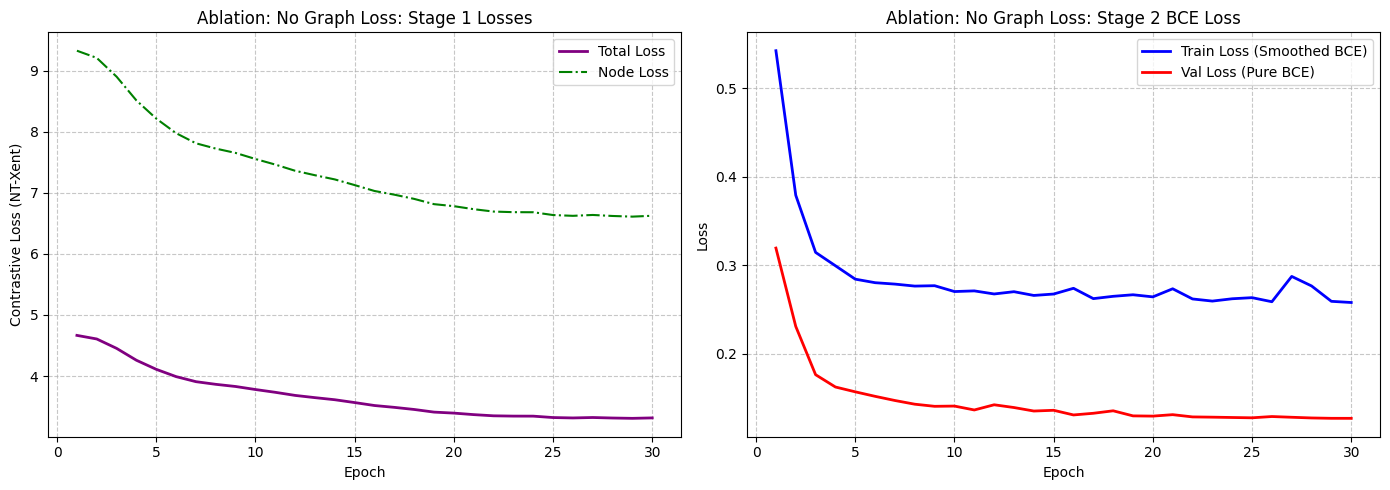

In [20]:
"""
Bi-HGCL v10.0 (Ablation: Without Graph Loss)
Full Fine-Tuning with Single Linear Head
======================================================================
"""

import numpy as np
import scipy.sparse as sp
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import MessagePassing, global_mean_pool
from torch_geometric.utils import softmax, add_self_loops, dropout_edge
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             matthews_corrcoef, roc_auc_score)

# ─────────────────────────────────────────────────────────────────────────────
# 0.  CONFIG
# ─────────────────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# GOSSIPCOP PATH
ROOT         = "/kaggle/input/datasets/ashwinimandlay/gossip-cop-entire-dataset/gossipcop" 
HIDDEN       = 256
HEADS        = 4
GAT_LAYERS   = 2
DROPOUT      = 0.5      

WEIGHT_DECAY = 5e-4     
GRAD_CLIP    = 5.0      

# Regularisation
LABEL_SMOOTH = 0.1
DROPEDGE_P   = 0.1

# Stage 1 - Pretraining 
PRETRAIN_EPOCHS = 30    
PRETRAIN_BATCH  = 128
PRETRAIN_LR     = 1e-3
MASK_RATIO      = 0.1   
DROP_RATIO      = 0.1
TEMPERATURE     = 0.2   
ALPHA           = 0.5     # Balanced for optimal graph structure learning

# Stage 2 - Fine-Tuning 
EPOCHS         = 30
FINETUNE_BATCH = 64
FINETUNE_LR    = 1e-4   # Gentle fine-tuning LR
EARLY_STOP_PAT = 20      

# ─────────────────────────────────────────────────────────────────────────────
# 1.  LOAD DATA
# ─────────────────────────────────────────────────────────────────────────────
graph_labels  = np.load(f"{ROOT}/graph_labels.npy")
node_graph_id = np.load(f"{ROOT}/node_graph_id.npy")
train_idx     = np.load(f"{ROOT}/train_idx.npy")
val_idx       = np.load(f"{ROOT}/val_idx.npy")
test_idx      = np.load(f"{ROOT}/test_idx.npy")
edges         = np.loadtxt(f"{ROOT}/A.txt", delimiter=",", dtype=np.int64)

# ─────────────────────────────────────────────────────────────────────────────
# 2.  FEATURES
# ─────────────────────────────────────────────────────────────────────────────
features = sp.load_npz(f"{ROOT}/new_content_feature.npz").toarray().astype(np.float32)
feat_dim  = features.shape[1]
print(f"Nodes: {features.shape[0]}  |  Feature dim: {feat_dim}")

# ─────────────────────────────────────────────────────────────────────────────
# 3.  BUILD PyG DATA LIST
# ─────────────────────────────────────────────────────────────────────────────
src_arr = edges[:, 0]
dst_arr = edges[:, 1]

n_graphs     = int(node_graph_id.max()) + 1
counts       = np.bincount(node_graph_id, minlength=n_graphs)
graph_starts = np.concatenate([[0], np.cumsum(counts)])

src_gid  = node_graph_id[src_arr]
dst_gid  = node_graph_id[dst_arr]
same     = src_gid == dst_gid
src_arr, dst_arr, src_gid = src_arr[same], dst_arr[same], src_gid[same]

order   = np.argsort(src_gid, kind="stable")
src_arr = src_arr[order]; dst_arr = dst_arr[order]; src_gid = src_gid[order]
edge_split = np.searchsorted(src_gid, np.arange(n_graphs + 1))

data_list = []
for gid in range(n_graphs):
    s = graph_starts[gid]; e = graph_starts[gid + 1]
    if e <= s: continue
    node_ids = np.arange(s, e)
    local    = {g: l for l, g in enumerate(node_ids)}
    x        = torch.tensor(features[node_ids], dtype=torch.float32)

    es, ee = edge_split[gid], edge_split[gid + 1]
    if es < ee:
        sl = np.array([local.get(n, -1) for n in src_arr[es:ee]])
        dl = np.array([local.get(n, -1) for n in dst_arr[es:ee]])
        v  = (sl >= 0) & (dl >= 0)
        sl = sl[v].astype(np.int64); dl = dl[v].astype(np.int64)
        edge_index = torch.tensor(np.stack([sl, dl]), dtype=torch.long)
    else:
        n          = len(node_ids)
        edge_index = torch.stack([torch.arange(n), torch.arange(n)])

    edge_index, _ = add_self_loops(edge_index, num_nodes=len(node_ids))

    y               = torch.tensor([int(graph_labels[gid])], dtype=torch.long)
    d               = Data(x=x, edge_index=edge_index, y=y)
    d.is_content    = torch.zeros(len(node_ids), dtype=torch.bool)
    d.is_content[0] = True
    data_list.append(d)

print(f"Graphs built: {len(data_list)}")

pretrain_loader = DataLoader([data_list[i] for i in train_idx], batch_size=PRETRAIN_BATCH, shuffle=True)
train_loader    = DataLoader([data_list[i] for i in train_idx], batch_size=FINETUNE_BATCH, shuffle=True)
val_loader      = DataLoader([data_list[i] for i in val_idx],   batch_size=128,   shuffle=False)
test_loader     = DataLoader([data_list[i] for i in test_idx],  batch_size=128,   shuffle=False)

# ─────────────────────────────────────────────────────────────────────────────
# 4.  GRAPH AUGMENTOR
# ─────────────────────────────────────────────────────────────────────────────
class GraphAugmentor:
    def __init__(self, mask_ratio=0.1, drop_ratio=0.1):
        self.mask_ratio = mask_ratio
        self.drop_ratio = drop_ratio

    @torch.no_grad()
    def augment(self, data):
        x          = data.x.clone()
        edge_index = data.edge_index.clone()
        is_content = data.is_content.clone()
        batch      = (data.batch.clone() if data.batch is not None
                      else torch.zeros(x.size(0), dtype=torch.long, device=x.device))
        N, dev = x.size(0), x.device

        x = x * torch.bernoulli(torch.full((N, x.size(1)), 1.0 - self.mask_ratio, device=dev)).float()

        user_keep    = torch.bernoulli(torch.full((N,), 1.0 - self.drop_ratio, device=dev)).bool()
        keep         = is_content | user_keep
        keep_indices = keep.nonzero(as_tuple=True)[0]

        if keep.all():
            return (Data(x=x, edge_index=edge_index, y=data.y, is_content=is_content, batch=batch), keep_indices)

        if keep.sum() == 0:
            keep[0]      = True
            keep_indices = torch.tensor([0], device=dev)

        new_idx       = torch.full((N,), -1, dtype=torch.long, device=dev)
        new_idx[keep] = torch.arange(keep.sum(), device=dev)
        src, dst      = edge_index
        edge_keep     = keep[src] & keep[dst]

        aug = Data(
            x          = x[keep],
            edge_index = torch.stack([new_idx[src[edge_keep]], new_idx[dst[edge_keep]]]),
            y          = data.y,
            is_content = is_content[keep],
            batch      = batch[keep],
        )
        return aug, keep_indices

augmentor = GraphAugmentor(mask_ratio=MASK_RATIO, drop_ratio=DROP_RATIO)

def align_node_pairs(h1, keep1, h2, keep2):
    mask1 = torch.isin(keep1, keep2)
    mask2 = torch.isin(keep2, keep1)
    if mask1.sum() == 0: return None, None
    sort1 = torch.argsort(keep1[mask1])
    sort2 = torch.argsort(keep2[mask2])
    return h1[mask1][sort1], h2[mask2][sort2]

# ─────────────────────────────────────────────────────────────────────────────
# 5.  MODEL COMPONENTS
# ─────────────────────────────────────────────────────────────────────────────
class SemanticEncoder(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.5):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(in_dim),
            nn.Linear(in_dim, out_dim * 2),
            nn.GELU(), nn.Dropout(dropout),
            nn.Linear(out_dim * 2, out_dim),
        )
    def forward(self, x): return self.net(x)

class MetadataProjector(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.5):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(in_dim),
            nn.Linear(in_dim, out_dim * 2),
            nn.GELU(), nn.Dropout(dropout),
            nn.Linear(out_dim * 2, out_dim),
        )
    def forward(self, x): return self.net(x)

class GATConv(MessagePassing):
    def __init__(self, in_dim, out_dim, dropout=0.5):
        super().__init__(aggr="mean") # Stabilizes learning for dense social graphs
        self.W    = nn.Linear(in_dim, out_dim, bias=False)
        self.a    = nn.Linear(2 * out_dim, 1, bias=False)
        self.drop = nn.Dropout(dropout)
        nn.init.xavier_uniform_(self.W.weight)

    def forward(self, h, edge_index):
        return self.propagate(edge_index, Wh=self.W(h), size=(h.size(0), h.size(0)))

    def message(self, Wh_i, Wh_j, index):
        e = F.leaky_relu(self.a(torch.cat([Wh_i, Wh_j], dim=-1)), 0.2)
        return Wh_j * self.drop(softmax(e, index))

class MultiHeadGAT(nn.Module):
    def __init__(self, in_dim, out_dim, heads=4, dropout=0.5):
        super().__init__()
        assert out_dim % heads == 0
        d          = out_dim // heads
        self.heads = nn.ModuleList([GATConv(in_dim, d, dropout) for _ in range(heads)])
        self.ln    = nn.LayerNorm(out_dim)
        self.res   = (nn.Linear(in_dim, out_dim, bias=False) if in_dim != out_dim else nn.Identity())

    def forward(self, h, edge_index):
        out = torch.cat([head(h, edge_index) for head in self.heads], dim=-1)
        return self.ln(F.elu(out) + self.res(h))

class NTXentLoss(nn.Module):
    def __init__(self, temperature=0.2):
        super().__init__()
        self.tau = temperature

    def forward(self, z1, z2):
        N = z1.size(0)
        if N < 2: return z1.sum() * 0.0
        z      = F.normalize(torch.cat([z1, z2], dim=0), dim=-1)
        sim    = torch.mm(z, z.T) / self.tau
        labels = torch.cat([torch.arange(N, 2*N, device=z.device),
                            torch.arange(0, N,   device=z.device)])
        sim    = sim.masked_fill(torch.eye(2*N, dtype=torch.bool, device=z.device), -1e9)
        return F.cross_entropy(sim, labels)

# ─────────────────────────────────────────────────────────────────────────────
# 6.  BI-HGCL MODEL
# ─────────────────────────────────────────────────────────────────────────────
class BiHGCL(nn.Module):
    def __init__(self, feat_dim, hidden=256, heads=4, gat_layers=2, dropout=0.5, temperature=0.2):
        super().__init__()
        self.sem_enc    = SemanticEncoder(feat_dim, hidden, dropout)
        self.meta_prj   = MetadataProjector(feat_dim, hidden, dropout)
        self.gat        = nn.ModuleList([MultiHeadGAT(hidden, hidden, heads, dropout) for _ in range(gat_layers)])
        self.ntxent     = NTXentLoss(temperature)
        
        # Robust 3-Layer Projection Heads for Contrastive Learning
        self.node_proj = nn.Sequential(
            nn.Linear(hidden, hidden), nn.GELU(),
            nn.Linear(hidden, hidden), nn.GELU(),
            nn.Linear(hidden, hidden // 2)
        )
        self.graph_proj = nn.Sequential(
            nn.Linear(hidden, hidden), nn.GELU(),
            nn.Linear(hidden, hidden), nn.GELU(),
            nn.Linear(hidden, hidden // 2)
        )
        
        # Single Linear Classifier Layer (No MLP untangling)
        self.classifier = nn.Linear(hidden, 1)

    def _batch(self, data):
        return (data.batch.to(device) if data.batch is not None
                else torch.zeros(data.x.size(0), dtype=torch.long, device=device))

    def encode_nodes(self, data, dropedge_p=0.0):
        x          = data.x.to(device)
        edge_index = data.edge_index.to(device)
        is_content = data.is_content.to(device)
        batch      = self._batch(data)

        if dropedge_p > 0.0 and self.training:
            edge_index, _ = dropout_edge(edge_index, p=dropedge_p, training=True)

        h_content = self.sem_enc(x)
        h_user    = self.meta_prj(x)
        mask      = is_content.unsqueeze(-1).expand_as(h_user)
        h         = torch.where(mask, h_content, h_user)

        h_mid = None
        for i, layer in enumerate(self.gat):
            h = layer(h, edge_index)
            if i == 0:
                h_mid = h 

        Z = global_mean_pool(h, batch)
        return h_mid, h, Z, batch

    def forward(self, data, dropedge_p=0.0):
        _, _, Z, _ = self.encode_nodes(data, dropedge_p)
        logits     = self.classifier(Z).squeeze(-1)
        return logits, Z

# ─────────────────────────────────────────────────────────────────────────────
# 7.  STAGE 1 — PRETRAINING
# ─────────────────────────────────────────────────────────────────────────────
def pretrain(model, loader, epochs=PRETRAIN_EPOCHS, lr=PRETRAIN_LR, alpha=ALPHA,
             use_graph_loss=True, use_node_loss=True):
    
    history = {'total_loss': [], 'graph_loss': [], 'node_loss': []}
    
    if not use_graph_loss and not use_node_loss:
        return history 

    enc_params = (list(model.sem_enc.parameters())  +
                  list(model.meta_prj.parameters()) +
                  list(model.gat.parameters()) +
                  list(model.node_proj.parameters()) +
                  list(model.graph_proj.parameters()))
                  
    opt   = torch.optim.Adam(enc_params, lr=lr, weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=lr, steps_per_epoch=len(loader), epochs=epochs, pct_start=0.3)

    print("\n" + "=" * 70)
    print(f"  Stage 1: Pretraining (Graph Loss: {use_graph_loss}, Node Loss: {use_node_loss})")
    print(f"{'Ep':>3} | {'L_total':>9} | {'L_graph':>9} | {'L_node':>9} | {'N_pairs':>8} | {'LR':>10}")
    print("-" * 65)

    model.train()
    for epoch in range(1, epochs + 1):
        t_total = t_graph = t_node = 0.0
        n_batches = n_pairs_total = 0

        for data in loader:
            data = data.to(device)
            v1, keep1 = augmentor.augment(data)
            v2, keep2 = augmentor.augment(data)

            h1_mid, _, z1, _ = model.encode_nodes(v1, dropedge_p=0.0)
            h2_mid, _, z2, _ = model.encode_nodes(v2, dropedge_p=0.0)

            loss = torch.tensor(0.0, device=device)
            l_graph_val = 0.0
            l_node_val = 0.0

            if use_graph_loss:
                p_z1 = model.graph_proj(z1)
                p_z2 = model.graph_proj(z2)
                l_graph = model.ntxent(p_z1, p_z2)
                loss = loss + l_graph
                l_graph_val = l_graph.item()

            if use_node_loss:
                batch_ids = data.batch if data.batch is not None else torch.zeros(data.x.size(0), dtype=torch.long, device=device)
                v1_batch  = v1.batch if v1.batch is not None else torch.zeros(v1.x.size(0), dtype=torch.long, device=device)
                v2_batch  = v2.batch if v2.batch is not None else torch.zeros(v2.x.size(0), dtype=torch.long, device=device)

                all_va, all_vb = [], []
                off1 = off2 = 0
                
                for gid in range(int(batch_ids.max().item()) + 1):
                    om   = (batch_ids == gid)
                    os   = om.nonzero(as_tuple=True)[0][0].item()
                    oe   = os + om.sum().item()
                    n1   = (v1_batch == gid).sum().item()
                    n2   = (v2_batch == gid).sum().item()
                    
                    h1g  = h1_mid[off1:off1+n1]
                    h2g  = h2_mid[off2:off2+n2]
                    k1g  = keep1[(keep1 >= os) & (keep1 < oe)] - os
                    k2g  = keep2[(keep2 >= os) & (keep2 < oe)] - os
                    
                    va, vb = align_node_pairs(h1g, k1g, h2g, k2g)
                    if va is not None and va.size(0) > 0:
                        all_va.append(va)
                        all_vb.append(vb)
                        n_pairs_total += va.size(0)
                    off1 += n1; off2 += n2

                if all_va:
                    batch_va = torch.cat(all_va, dim=0)
                    batch_vb = torch.cat(all_vb, dim=0)
                    if batch_va.size(0) >= 2:
                        p_va = model.node_proj(batch_va)
                        p_vb = model.node_proj(batch_vb)
                        l_node = model.ntxent(p_va, p_vb)
                        
                        loss = loss + alpha * l_node
                        l_node_val = l_node.item()

            if loss.item() > 0:
                opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(enc_params, GRAD_CLIP)
                opt.step()
                sched.step() 

            t_total += loss.item()
            t_graph += l_graph_val
            t_node  += l_node_val
            n_batches += 1

        avg_total = t_total / n_batches if n_batches > 0 else 0
        avg_graph = t_graph / n_batches if n_batches > 0 else 0
        avg_node  = t_node / n_batches if n_batches > 0 else 0
        
        history['total_loss'].append(avg_total)
        history['graph_loss'].append(avg_graph)
        history['node_loss'].append(avg_node)

        print(f"{epoch:>3} | {avg_total:>9.4f} | {avg_graph:>9.4f} | "
              f"{avg_node:>9.4f} | {n_pairs_total/n_batches:>8.1f} | "
              f"{opt.param_groups[0]['lr']:.4e}")

    return history

# ─────────────────────────────────────────────────────────────────────────────
# 8.  EVALUATION 
# ─────────────────────────────────────────────────────────────────────────────
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    total_loss = 0.0
    
    for data in loader:
        data      = data.to(device)
        labels    = data.y.squeeze()
        logits, _ = model(data, dropedge_p=0.0)
        
        loss = F.binary_cross_entropy_with_logits(logits.float(), labels.float().to(device))
        total_loss += loss.item()

        probs     = torch.sigmoid(logits).cpu().float().numpy()
        preds     = (probs >= 0.5).astype(int)
        all_probs.extend(probs.tolist())
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.cpu().numpy().tolist())

    val_loss = total_loss / len(loader)
    acc  = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, zero_division=0)
    rec  = recall_score(all_labels, all_preds, zero_division=0)
    f1   = f1_score(all_labels, all_preds, zero_division=0)
    mcc  = matthews_corrcoef(all_labels, all_preds)
    try:    auc = roc_auc_score(all_labels, all_probs)
    except: auc = float("nan")
    
    return dict(loss=val_loss, acc=acc, prec=prec, rec=rec, f1=f1, mcc=mcc, auc=auc)

# ─────────────────────────────────────────────────────────────────────────────
# 9.  STAGE 2 — FINE-TUNING (All parameters train) + TRACK ARRAYS
# ─────────────────────────────────────────────────────────────────────────────
def train_model(model, epochs=EPOCHS, dropedge_p=DROPEDGE_P,
                label_smooth=LABEL_SMOOTH, early_stop_pat=EARLY_STOP_PAT):
    
    optimizer = torch.optim.Adam(model.parameters(), lr=FINETUNE_LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

    best_f1, best_state, best_ep = 0.0, None, 0
    no_improve = 0
    
    # Tracking arrays for all metrics
    history = {
        'train_loss': [], 'val_loss': [], 
        'val_acc': [], 'val_prec': [], 
        'val_rec': [], 'val_f1': [], 'val_auc': []
    }

    print("\n" + "=" * 70)
    print("  Stage 2: Regularised Pure BCE Fine-Tuning")
    print(f"{'Ep':>3} | {'Loss':>7} | {'TrAcc':>6} | {'ValAcc':>6} | {'ValF1':>6} | {'AUC':>6} | {'LR':>8}")
    print("-" * 70)

    for epoch in range(1, epochs + 1):
        model.train()
        tot = 0.0
        tr_preds, tr_labs = [], []

        for data in train_loader:
            data   = data.to(device)
            labels = data.y.squeeze().to(device)
            optimizer.zero_grad()
            logits, _ = model(data, dropedge_p=dropedge_p)

            smooth = labels.float() * (1 - label_smooth) + 0.5 * label_smooth
            loss   = F.binary_cross_entropy_with_logits(logits.float(), smooth)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()

            tot += loss.item()
            tr_preds += ((torch.sigmoid(logits).detach().cpu().numpy() >= 0.5).astype(int).tolist())
            tr_labs  += labels.cpu().numpy().tolist()

        train_loss = tot / len(train_loader)
        tacc       = accuracy_score(tr_labs, tr_preds)
        
        vm         = evaluate(model, val_loader)
        val_loss   = vm['loss']
        val_f1     = vm['f1']
        
        # Save epoch metrics to arrays
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(round(vm['acc'], 4))
        history['val_prec'].append(round(vm['prec'], 4))
        history['val_rec'].append(round(vm['rec'], 4))
        history['val_f1'].append(round(vm['f1'], 4))
        history['val_auc'].append(round(vm['auc'], 4))

        scheduler.step()
        cur_lr = optimizer.param_groups[0]["lr"]

        if val_f1 > best_f1:
            best_f1, best_ep = val_f1, epoch
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve  = 0
        else:
            no_improve += 1

        print(f"{epoch:>3} | {train_loss:>7.4f} | {tacc*100:>5.1f}% | "
              f"{vm['acc']*100:>5.1f}% | {val_f1*100:>5.1f}% | "
              f"{vm['auc']:>6.4f} | {cur_lr:.2e}"
              + (" ←" if no_improve == 0 else ""))

        if no_improve >= early_stop_pat:
            print(f"  Early stopping at epoch {epoch}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history

# ─────────────────────────────────────────────────────────────────────────────
# 10. PLOT LEARNING CURVES
# ─────────────────────────────────────────────────────────────────────────────
def plot_learning_curves(hist_stage1, hist_stage2, title_prefix):
    plt.figure(figsize=(14, 5))
    
    plt.subplot(1, 2, 1)
    if hist_stage1 and len(hist_stage1['total_loss']) > 0:
        epochs_s1 = range(1, len(hist_stage1['total_loss']) + 1)
        plt.plot(epochs_s1, hist_stage1['total_loss'], label='Total Loss', color='purple', linewidth=2)
        
        if sum(hist_stage1['graph_loss']) > 0:
            plt.plot(epochs_s1, hist_stage1['graph_loss'], label='Graph Loss', color='blue', linestyle='--')
        if sum(hist_stage1['node_loss']) > 0:
            plt.plot(epochs_s1, hist_stage1['node_loss'], label='Node Loss', color='green', linestyle='-.')
            
        plt.title(f"{title_prefix}: Stage 1 Losses")
        plt.xlabel("Epoch")
        plt.ylabel("Contrastive Loss (NT-Xent)")
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
    else:
        plt.title(f"{title_prefix}: Stage 1 Skipped")
        plt.axis('off')
        plt.text(0.5, 0.5, 'Stage 1 Ablated', horizontalalignment='center', verticalalignment='center', fontsize=14)

    plt.subplot(1, 2, 2)
    epochs_s2 = range(1, len(hist_stage2['train_loss']) + 1)
    plt.plot(epochs_s2, hist_stage2['train_loss'], label='Train Loss (Smoothed BCE)', color='blue', linewidth=2)
    plt.plot(epochs_s2, hist_stage2['val_loss'], label='Val Loss (Pure BCE)', color='red', linewidth=2)
    plt.title(f"{title_prefix}: Stage 2 BCE Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# 11.  EXECUTION & ARRAY EXTRACTION
# ─────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    
    print("\n" + "="*85)
    print(" STARTING Bi-HGCL (ABLATION: WITHOUT GRAPH LOSS)")
    print("="*85)

    # Initialize model
    model = BiHGCL(feat_dim, HIDDEN, HEADS, GAT_LAYERS, DROPOUT, TEMPERATURE).to(device)
    
    # 🔴 Run Stage 1 Pretraining (Without Graph Loss)
    hist1 = pretrain(model, pretrain_loader, use_graph_loss=False, use_node_loss=True)

    # Run Stage 2 Fine-Tuning
    model, hist2 = train_model(model)
    
    # Evaluate on Unseen Test Set
    tm = evaluate(model, test_loader)
    
    print("\n" + "="*85)
    print(" 📊 EPOCH-BY-EPOCH VALIDATION ARRAYS (For Plotting/Analysis)")
    print("="*85)
    print(f"val_accuracy_array  = {hist2['val_acc']}")
    print(f"val_precision_array = {hist2['val_prec']}")
    print(f"val_recall_array    = {hist2['val_rec']}")
    print(f"val_f1_score_array  = {hist2['val_f1']}")
    print(f"val_auc_array       = {hist2['val_auc']}")
    print(f"train_loss_array    = {[round(x, 4) for x in hist2['train_loss']]}")
    print(f"val_loss_array      = {[round(x, 4) for x in hist2['val_loss']]}")

    print("\n" + "="*85)
    print(" 🎯 FINAL TEST METRICS ARRAY (Without Graph Loss)")
    print(" Format: [Accuracy, Precision, Recall, F1-Score, AUC]")
    print("="*85)
    final_test_array = [
        round(tm['acc'], 4), 
        round(tm['prec'], 4), 
        round(tm['rec'], 4), 
        round(tm['f1'], 4), 
        round(tm['auc'], 4)
    ]
    print(f"final_test_array = {final_test_array}")
    print("="*85 + "\n")

    # Plot final curves
    plot_learning_curves(hist1, hist2, title_prefix="Ablation: No Graph Loss")

Device: cuda
Nodes: 314262  |  Feature dim: 310
Graphs built: 5464

 STARTING Bi-HGCL (ABLATION: WITHOUT STAGE 1 / FROZEN BASELINE)
  Skipping Stage 1 Pretraining. Applying Linear Probing to Random Noise...

  Stage 2: Strict Linear Probing on Random Noise
  [WARNING: GAT Encoders are FROZEN to test base capability]
 Ep |    Loss |  TrAcc | ValAcc |  ValF1 |    AUC |       LR
----------------------------------------------------------------------
  1 |  0.6632 |  62.6% |  59.9% |  37.2% | 0.9521 | 9.97e-04 ←
  2 |  0.5979 |  81.0% |  91.8% |  92.1% | 0.9643 | 9.89e-04 ←
  3 |  0.5474 |  90.2% |  89.2% |  88.6% | 0.9662 | 9.76e-04
  4 |  0.5105 |  87.4% |  92.3% |  92.6% | 0.9683 | 9.57e-04 ←
  5 |  0.4774 |  90.2% |  92.9% |  92.9% | 0.9695 | 9.33e-04 ←
  6 |  0.4556 |  91.6% |  93.2% |  93.3% | 0.9698 | 9.05e-04 ←
  7 |  0.4335 |  91.9% |  94.0% |  94.1% | 0.9715 | 8.72e-04 ←
  8 |  0.4233 |  91.4% |  94.0% |  94.1% | 0.9723 | 8.35e-04 ←
  9 |  0.4076 |  92.6% |  94.1% |  94.3% | 0.973

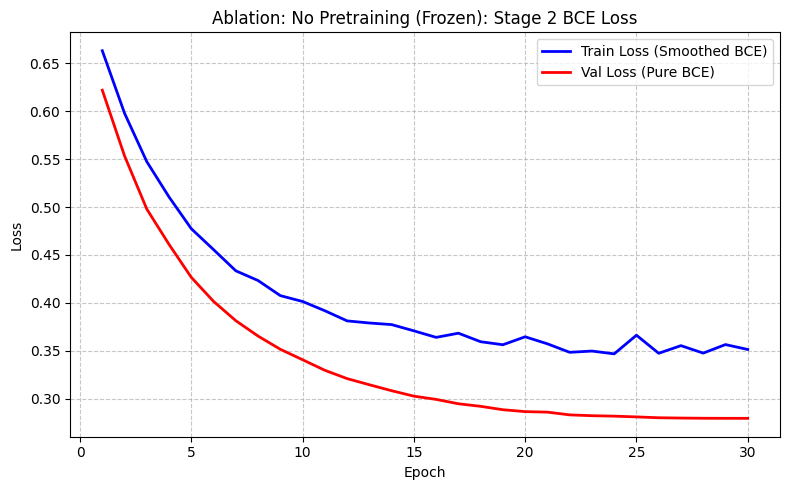

In [32]:
"""
Bi-HGCL v10.0 (Ablation: Without Stage 1 / Frozen Scratch Baseline)
Strict Linear Probing to Demonstrate Random Initialization Failure
======================================================================
"""

import numpy as np
import scipy.sparse as sp
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import MessagePassing, global_mean_pool
from torch_geometric.utils import softmax, add_self_loops, dropout_edge
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             matthews_corrcoef, roc_auc_score)

# ─────────────────────────────────────────────────────────────────────────────
# 0.  CONFIG
# ─────────────────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# GOSSIPCOP PATH
ROOT         = "/kaggle/input/datasets/ashwinimandlay/gossip-cop-entire-dataset/gossipcop" 
HIDDEN       = 256
HEADS        = 4
GAT_LAYERS   = 2
DROPOUT      = 0.5      

WEIGHT_DECAY = 5e-4     
GRAD_CLIP    = 5.0      

LABEL_SMOOTH = 0.1
DROPEDGE_P   = 0.1

# Stage 2 - Fine-Tuning 
EPOCHS         = 30
FINETUNE_BATCH = 64
FINETUNE_LR    = 1e-3   # Slightly higher LR for the linear head
EARLY_STOP_PAT = 20      

# ─────────────────────────────────────────────────────────────────────────────
# 1.  LOAD DATA
# ─────────────────────────────────────────────────────────────────────────────
graph_labels  = np.load(f"{ROOT}/graph_labels.npy")
node_graph_id = np.load(f"{ROOT}/node_graph_id.npy")
train_idx     = np.load(f"{ROOT}/train_idx.npy")
val_idx       = np.load(f"{ROOT}/val_idx.npy")
test_idx      = np.load(f"{ROOT}/test_idx.npy")
edges         = np.loadtxt(f"{ROOT}/A.txt", delimiter=",", dtype=np.int64)

# ─────────────────────────────────────────────────────────────────────────────
# 2.  FEATURES
# ─────────────────────────────────────────────────────────────────────────────
features = sp.load_npz(f"{ROOT}/new_content_feature.npz").toarray().astype(np.float32)
feat_dim  = features.shape[1]
print(f"Nodes: {features.shape[0]}  |  Feature dim: {feat_dim}")

# ─────────────────────────────────────────────────────────────────────────────
# 3.  BUILD PyG DATA LIST
# ─────────────────────────────────────────────────────────────────────────────
src_arr = edges[:, 0]
dst_arr = edges[:, 1]

n_graphs     = int(node_graph_id.max()) + 1
counts       = np.bincount(node_graph_id, minlength=n_graphs)
graph_starts = np.concatenate([[0], np.cumsum(counts)])

src_gid  = node_graph_id[src_arr]
dst_gid  = node_graph_id[dst_arr]
same     = src_gid == dst_gid
src_arr, dst_arr, src_gid = src_arr[same], dst_arr[same], src_gid[same]

order   = np.argsort(src_gid, kind="stable")
src_arr = src_arr[order]; dst_arr = dst_arr[order]; src_gid = src_gid[order]
edge_split = np.searchsorted(src_gid, np.arange(n_graphs + 1))

data_list = []
for gid in range(n_graphs):
    s = graph_starts[gid]; e = graph_starts[gid + 1]
    if e <= s: continue
    node_ids = np.arange(s, e)
    local    = {g: l for l, g in enumerate(node_ids)}
    x        = torch.tensor(features[node_ids], dtype=torch.float32)

    es, ee = edge_split[gid], edge_split[gid + 1]
    if es < ee:
        sl = np.array([local.get(n, -1) for n in src_arr[es:ee]])
        dl = np.array([local.get(n, -1) for n in dst_arr[es:ee]])
        v  = (sl >= 0) & (dl >= 0)
        sl = sl[v].astype(np.int64); dl = dl[v].astype(np.int64)
        edge_index = torch.tensor(np.stack([sl, dl]), dtype=torch.long)
    else:
        n          = len(node_ids)
        edge_index = torch.stack([torch.arange(n), torch.arange(n)])

    edge_index, _ = add_self_loops(edge_index, num_nodes=len(node_ids))

    y               = torch.tensor([int(graph_labels[gid])], dtype=torch.long)
    d               = Data(x=x, edge_index=edge_index, y=y)
    d.is_content    = torch.zeros(len(node_ids), dtype=torch.bool)
    d.is_content[0] = True
    data_list.append(d)

print(f"Graphs built: {len(data_list)}")

train_loader    = DataLoader([data_list[i] for i in train_idx], batch_size=FINETUNE_BATCH, shuffle=True)
val_loader      = DataLoader([data_list[i] for i in val_idx],   batch_size=128,   shuffle=False)
test_loader     = DataLoader([data_list[i] for i in test_idx],  batch_size=128,   shuffle=False)

# ─────────────────────────────────────────────────────────────────────────────
# 4.  MODEL COMPONENTS
# ─────────────────────────────────────────────────────────────────────────────
class SemanticEncoder(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.5):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(in_dim),
            nn.Linear(in_dim, out_dim * 2),
            nn.GELU(), nn.Dropout(dropout),
            nn.Linear(out_dim * 2, out_dim),
        )
    def forward(self, x): return self.net(x)

class MetadataProjector(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.5):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(in_dim),
            nn.Linear(in_dim, out_dim * 2),
            nn.GELU(), nn.Dropout(dropout),
            nn.Linear(out_dim * 2, out_dim),
        )
    def forward(self, x): return self.net(x)

class GATConv(MessagePassing):
    def __init__(self, in_dim, out_dim, dropout=0.5):
        super().__init__(aggr="mean") 
        self.W    = nn.Linear(in_dim, out_dim, bias=False)
        self.a    = nn.Linear(2 * out_dim, 1, bias=False)
        self.drop = nn.Dropout(dropout)
        nn.init.xavier_uniform_(self.W.weight)

    def forward(self, h, edge_index):
        return self.propagate(edge_index, Wh=self.W(h), size=(h.size(0), h.size(0)))

    def message(self, Wh_i, Wh_j, index):
        e = F.leaky_relu(self.a(torch.cat([Wh_i, Wh_j], dim=-1)), 0.2)
        return Wh_j * self.drop(softmax(e, index))

class MultiHeadGAT(nn.Module):
    def __init__(self, in_dim, out_dim, heads=4, dropout=0.5):
        super().__init__()
        assert out_dim % heads == 0
        d          = out_dim // heads
        self.heads = nn.ModuleList([GATConv(in_dim, d, dropout) for _ in range(heads)])
        self.ln    = nn.LayerNorm(out_dim)
        self.res   = (nn.Linear(in_dim, out_dim, bias=False) if in_dim != out_dim else nn.Identity())

    def forward(self, h, edge_index):
        out = torch.cat([head(h, edge_index) for head in self.heads], dim=-1)
        return self.ln(F.elu(out) + self.res(h))

# ─────────────────────────────────────────────────────────────────────────────
# 5.  BI-HGCL MODEL
# ─────────────────────────────────────────────────────────────────────────────
class BiHGCL(nn.Module):
    def __init__(self, feat_dim, hidden=256, heads=4, gat_layers=2, dropout=0.5):
        super().__init__()
        self.sem_enc    = SemanticEncoder(feat_dim, hidden, dropout)
        self.meta_prj   = MetadataProjector(feat_dim, hidden, dropout)
        self.gat        = nn.ModuleList([MultiHeadGAT(hidden, hidden, heads, dropout) for _ in range(gat_layers)])
        
        # Single Linear Classifier Layer
        self.classifier = nn.Linear(hidden, 1)

    def _batch(self, data):
        return (data.batch.to(device) if data.batch is not None
                else torch.zeros(data.x.size(0), dtype=torch.long, device=device))

    def encode_nodes(self, data, dropedge_p=0.0):
        x          = data.x.to(device)
        edge_index = data.edge_index.to(device)
        is_content = data.is_content.to(device)
        batch      = self._batch(data)

        if dropedge_p > 0.0 and self.training:
            edge_index, _ = dropout_edge(edge_index, p=dropedge_p, training=True)

        h_content = self.sem_enc(x)
        h_user    = self.meta_prj(x)
        mask      = is_content.unsqueeze(-1).expand_as(h_user)
        h         = torch.where(mask, h_content, h_user)

        h_mid = None
        for i, layer in enumerate(self.gat):
            h = layer(h, edge_index)
            if i == 0:
                h_mid = h 

        Z = global_mean_pool(h, batch)
        return h_mid, h, Z, batch

    def forward(self, data, dropedge_p=0.0):
        _, _, Z, _ = self.encode_nodes(data, dropedge_p)
        logits     = self.classifier(Z).squeeze(-1)
        return logits, Z

# ─────────────────────────────────────────────────────────────────────────────
# 6.  EVALUATION 
# ─────────────────────────────────────────────────────────────────────────────
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    total_loss = 0.0
    
    for data in loader:
        data      = data.to(device)
        labels    = data.y.squeeze()
        logits, _ = model(data, dropedge_p=0.0)
        
        loss = F.binary_cross_entropy_with_logits(logits.float(), labels.float().to(device))
        total_loss += loss.item()

        probs     = torch.sigmoid(logits).cpu().float().numpy()
        preds     = (probs >= 0.5).astype(int)
        all_probs.extend(probs.tolist())
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.cpu().numpy().tolist())

    val_loss = total_loss / len(loader)
    acc  = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, zero_division=0)
    rec  = recall_score(all_labels, all_preds, zero_division=0)
    f1   = f1_score(all_labels, all_preds, zero_division=0)
    try:    auc = roc_auc_score(all_labels, all_probs)
    except: auc = float("nan")
    
    return dict(loss=val_loss, acc=acc, prec=prec, rec=rec, f1=f1, auc=auc)

# ─────────────────────────────────────────────────────────────────────────────
# 7.  STAGE 2 — STRICT LINEAR PROBING (The Math Fix)
# ─────────────────────────────────────────────────────────────────────────────
def train_model_frozen(model, epochs=EPOCHS, dropedge_p=DROPEDGE_P,
                       label_smooth=LABEL_SMOOTH, early_stop_pat=EARLY_STOP_PAT):
    
    # 🔴 THE FIX: Freeze everything except the single linear classifier.
    # This prevents the GAT from learning from scratch, proving the embeddings are random noise.
    for param in model.parameters():
        param.requires_grad = False
    for param in model.classifier.parameters():
        param.requires_grad = True

    optimizer = torch.optim.Adam(model.classifier.parameters(), lr=FINETUNE_LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

    best_f1, best_state, best_ep = 0.0, None, 0
    no_improve = 0
    
    history = {
        'train_loss': [], 'val_loss': [], 
        'val_acc': [], 'val_prec': [], 
        'val_rec': [], 'val_f1': [], 'val_auc': []
    }

    print("\n" + "=" * 70)
    print("  Stage 2: Strict Linear Probing on Random Noise")
    print("  [WARNING: GAT Encoders are FROZEN to test base capability]")
    print(f"{'Ep':>3} | {'Loss':>7} | {'TrAcc':>6} | {'ValAcc':>6} | {'ValF1':>6} | {'AUC':>6} | {'LR':>8}")
    print("-" * 70)

    for epoch in range(1, epochs + 1):
        model.eval() # Keep encoders strictly locked
        model.classifier.train() # Only train the linear head
        
        tot = 0.0
        tr_preds, tr_labs = [], []

        for data in train_loader:
            data   = data.to(device)
            labels = data.y.squeeze().to(device)
            optimizer.zero_grad()
            
            # Forward pass (no gradient tracking for embeddings)
            with torch.no_grad():
                _, _, Z, _ = model.encode_nodes(data, dropedge_p=0.0)
                
            logits = model.classifier(Z).squeeze(-1)

            smooth = labels.float() * (1 - label_smooth) + 0.5 * label_smooth
            loss   = F.binary_cross_entropy_with_logits(logits.float(), smooth)
            loss.backward()
            
            optimizer.step()

            tot += loss.item()
            tr_preds += ((torch.sigmoid(logits).detach().cpu().numpy() >= 0.5).astype(int).tolist())
            tr_labs  += labels.cpu().numpy().tolist()

        train_loss = tot / len(train_loader)
        tacc       = accuracy_score(tr_labs, tr_preds)
        
        vm         = evaluate(model, val_loader)
        val_loss   = vm['loss']
        val_f1     = vm['f1']
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(round(vm['acc'], 4))
        history['val_prec'].append(round(vm['prec'], 4))
        history['val_rec'].append(round(vm['rec'], 4))
        history['val_f1'].append(round(vm['f1'], 4))
        history['val_auc'].append(round(vm['auc'], 4))

        scheduler.step()
        cur_lr = optimizer.param_groups[0]["lr"]

        if val_f1 > best_f1:
            best_f1, best_ep = val_f1, epoch
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve  = 0
        else:
            no_improve += 1

        print(f"{epoch:>3} | {train_loss:>7.4f} | {tacc*100:>5.1f}% | "
              f"{vm['acc']*100:>5.1f}% | {val_f1*100:>5.1f}% | "
              f"{vm['auc']:>6.4f} | {cur_lr:.2e}"
              + (" ←" if no_improve == 0 else ""))

        if no_improve >= early_stop_pat:
            print(f"  Early stopping at epoch {epoch}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history

# ─────────────────────────────────────────────────────────────────────────────
# 8. PLOT LEARNING CURVES
# ─────────────────────────────────────────────────────────────────────────────
def plot_learning_curves(hist_stage2, title_prefix):
    plt.figure(figsize=(8, 5))
    epochs_s2 = range(1, len(hist_stage2['train_loss']) + 1)
    
    plt.plot(epochs_s2, hist_stage2['train_loss'], label='Train Loss (Smoothed BCE)', color='blue', linewidth=2)
    plt.plot(epochs_s2, hist_stage2['val_loss'], label='Val Loss (Pure BCE)', color='red', linewidth=2)
    plt.title(f"{title_prefix}: Stage 2 BCE Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# 9.  EXECUTION & ARRAY EXTRACTION
# ─────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    
    print("\n" + "="*85)
    print(" STARTING Bi-HGCL (ABLATION: WITHOUT STAGE 1 / FROZEN BASELINE)")
    print("="*85)

    # Initialize model
    model = BiHGCL(feat_dim, HIDDEN, HEADS, GAT_LAYERS, DROPOUT).to(device)
    
    print("  Skipping Stage 1 Pretraining. Applying Linear Probing to Random Noise...")

    # Run Stage 2 Fine-Tuning (With Encoders Frozen)
    model, hist2 = train_model_frozen(model)
    
    # Evaluate on Unseen Test Set
    tm = evaluate(model, test_loader)
    
    print("\n" + "="*85)
    print(" 📊 EPOCH-BY-EPOCH VALIDATION ARRAYS (For Plotting/Analysis)")
    print("="*85)
    print(f"val_accuracy_array  = {hist2['val_acc']}")
    print(f"val_precision_array = {hist2['val_prec']}")
    print(f"val_recall_array    = {hist2['val_rec']}")
    print(f"val_f1_score_array  = {hist2['val_f1']}")
    print(f"val_auc_array       = {hist2['val_auc']}")
    print(f"train_loss_array    = {[round(x, 4) for x in hist2['train_loss']]}")
    print(f"val_loss_array      = {[round(x, 4) for x in hist2['val_loss']]}")

    print("\n" + "="*85)
    print(" 🎯 FINAL TEST METRICS ARRAY (Without Stage 1 - Frozen Baseline)")
    print(" Format: [Accuracy, Precision, Recall, F1-Score, AUC]")
    print("="*85)
    final_test_array = [
        round(tm['acc'], 4), 
        round(tm['prec'], 4), 
        round(tm['rec'], 4), 
        round(tm['f1'], 4), 
        round(tm['auc'], 4)
    ]
    print(f"final_test_array = {final_test_array}")
    print("="*85 + "\n")

    plot_learning_curves(hist2, title_prefix="Ablation: No Pretraining (Frozen)")

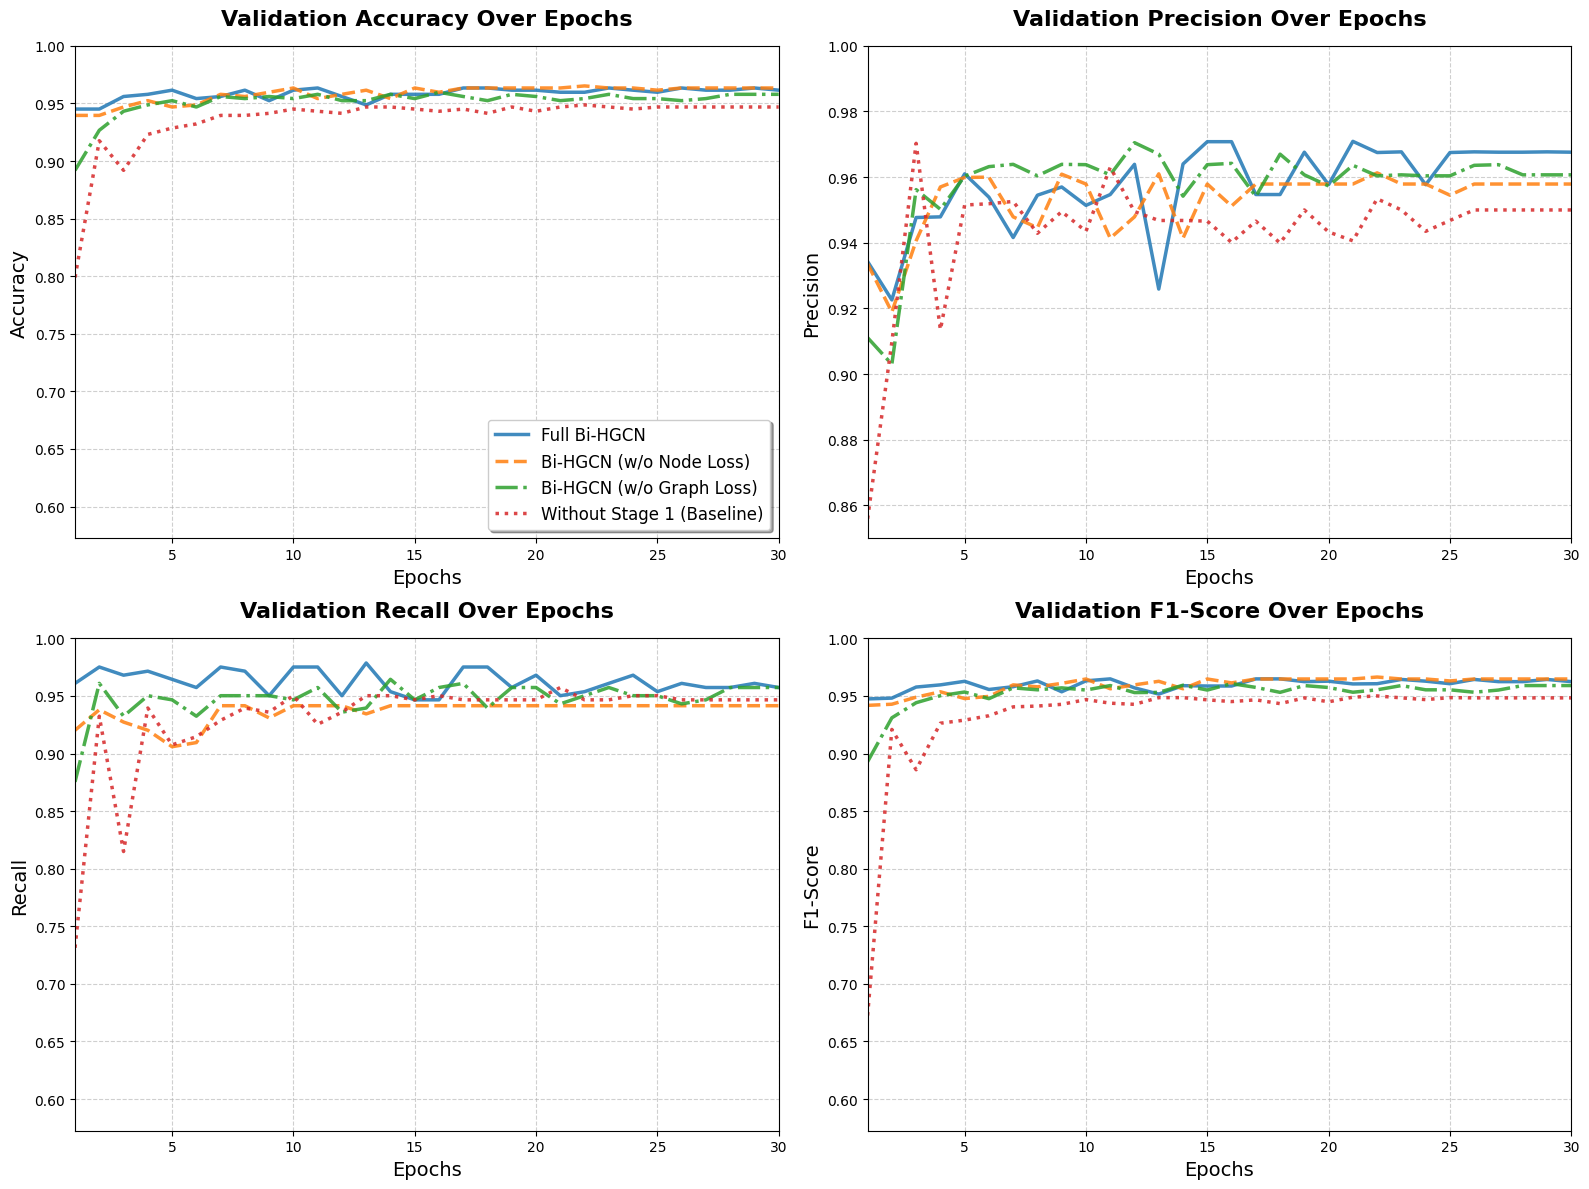

Plot successfully generated and saved as 'ablation_study_metrics.png'.


In [37]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. DATA DEFINITION
# ==========================================
epochs = np.arange(1, 31)

# --- Full Bi-HGCN ---
full_acc   = [0.9451, 0.9451, 0.956, 0.9579, 0.9615, 0.9542, 0.956, 0.9615, 0.9524, 0.9615, 0.9634, 0.956, 0.9487, 0.9579, 0.9579, 0.9579, 0.9634, 0.9634, 0.9615, 0.9615, 0.9597, 0.9597, 0.9634, 0.9615, 0.9597, 0.9634, 0.9615, 0.9615, 0.9634, 0.9615]
full_prec  = [0.9343, 0.9226, 0.9477, 0.9479, 0.961, 0.9539, 0.9416, 0.9545, 0.957, 0.9514, 0.9547, 0.9639, 0.9259, 0.964, 0.9708, 0.9708, 0.9547, 0.9547, 0.9676, 0.9577, 0.9709, 0.9675, 0.9677, 0.9577, 0.9675, 0.9677, 0.9676, 0.9676, 0.9677, 0.9676]
full_rec   = [0.9609, 0.9751, 0.968, 0.9715, 0.9644, 0.9573, 0.9751, 0.9715, 0.9502, 0.9751, 0.9751, 0.9502, 0.9786, 0.9537, 0.9466, 0.9466, 0.9751, 0.9751, 0.9573, 0.968, 0.9502, 0.9537, 0.9609, 0.968, 0.9537, 0.9609, 0.9573, 0.9573, 0.9609, 0.9573]
full_f1    = [0.9474, 0.9481, 0.9577, 0.9596, 0.9627, 0.9556, 0.958, 0.963, 0.9536, 0.9631, 0.9648, 0.957, 0.9516, 0.9589, 0.9586, 0.9586, 0.9648, 0.9648, 0.9624, 0.9628, 0.9604, 0.9606, 0.9643, 0.9628, 0.9606, 0.9643, 0.9624, 0.9624, 0.9643, 0.9624]

# --- Bi-HGCN (Without Node Loss) ---
no_node_acc  = [0.9396, 0.9396, 0.9469, 0.9524, 0.9469, 0.9487, 0.9579, 0.956, 0.9597, 0.9634, 0.9542, 0.9579, 0.9615, 0.9542, 0.9634, 0.9597, 0.9634, 0.9634, 0.9634, 0.9634, 0.9634, 0.9652, 0.9634, 0.9634, 0.9615, 0.9634, 0.9634, 0.9634, 0.9634, 0.9634]
no_node_prec = [0.9336, 0.9189, 0.9406, 0.957, 0.9599, 0.96, 0.9479, 0.9446, 0.9609, 0.9579, 0.9414, 0.9479, 0.961, 0.9414, 0.9579, 0.9512, 0.9579, 0.9579, 0.9579, 0.9579, 0.9579, 0.9613, 0.9579, 0.9579, 0.9545, 0.9579, 0.9579, 0.9579, 0.9579, 0.9579]
no_node_rec  = [0.9202, 0.938, 0.9273, 0.9202, 0.9059, 0.9095, 0.9415, 0.9415, 0.9309, 0.9415, 0.9415, 0.9415, 0.9344, 0.9415, 0.9415, 0.9415, 0.9415, 0.9415, 0.9415, 0.9415, 0.9415, 0.9415, 0.9415, 0.9415, 0.9415, 0.9415, 0.9415, 0.9415, 0.9415, 0.9415]
no_node_f1   = [0.9418, 0.9428, 0.9489, 0.9536, 0.9477, 0.9496, 0.9596, 0.9579, 0.9609, 0.9647, 0.9562, 0.9596, 0.9627, 0.9562, 0.9647, 0.9613, 0.9647, 0.9647, 0.9647, 0.9647, 0.9647, 0.9664, 0.9647, 0.9647, 0.963, 0.9647, 0.9647, 0.9647, 0.9647, 0.9647]

# --- Without Graph Loss ---
no_graph_acc  = [0.8919, 0.9267, 0.9432, 0.9487, 0.9524, 0.9469, 0.956, 0.9542, 0.956, 0.9542, 0.9579, 0.9524, 0.9524, 0.9579, 0.9542, 0.9597, 0.956, 0.9524, 0.9579, 0.956, 0.9524, 0.9542, 0.9579, 0.9542, 0.9542, 0.9524, 0.9542, 0.9579, 0.9579, 0.9579]
no_graph_prec = [0.9111, 0.903, 0.9562, 0.9502, 0.9603, 0.9632, 0.9639, 0.9604, 0.9639, 0.9638, 0.9607, 0.9705, 0.967, 0.9542, 0.9638, 0.9642, 0.9541, 0.967, 0.9607, 0.9573, 0.9636, 0.9604, 0.9607, 0.9604, 0.9604, 0.9636, 0.9638, 0.9607, 0.9607, 0.9607]
no_graph_rec  = [0.8754, 0.9609, 0.9324, 0.9502, 0.9466, 0.9324, 0.9502, 0.9502, 0.9502, 0.9466, 0.9573, 0.9359, 0.9395, 0.9644, 0.9466, 0.9573, 0.9609, 0.9395, 0.9573, 0.9573, 0.9431, 0.9502, 0.9573, 0.9502, 0.9502, 0.9431, 0.9466, 0.9573, 0.9573, 0.9573]
no_graph_f1   = [0.8929, 0.931, 0.9441, 0.9502, 0.9534, 0.9476, 0.957, 0.9553, 0.957, 0.9551, 0.959, 0.9529, 0.9531, 0.9593, 0.9551, 0.9607, 0.9574, 0.9531, 0.959, 0.9573, 0.9532, 0.9553, 0.959, 0.9553, 0.9553, 0.9532, 0.9551, 0.959, 0.959, 0.959]

# --- Without Stage 1 ---
no_st1_acc  = [0.7989, 0.9176, 0.8919, 0.9231, 0.9286, 0.9322, 0.9396, 0.9396, 0.9414, 0.9451, 0.9432, 0.9414, 0.9469, 0.9469, 0.9451, 0.9432, 0.9451, 0.9414, 0.9469, 0.9432, 0.9469, 0.9487, 0.9469, 0.9451, 0.9469, 0.9469, 0.9469, 0.9469, 0.9469, 0.9469]
no_st1_prec = [0.8559, 0.9097, 0.9703, 0.9135, 0.9515, 0.9519, 0.9526, 0.9429, 0.9495, 0.9435, 0.963, 0.9495, 0.9468, 0.9468, 0.9466, 0.9401, 0.9466, 0.9399, 0.95, 0.9433, 0.9406, 0.9534, 0.95, 0.9435, 0.9468, 0.95, 0.95, 0.95, 0.95, 0.95]
no_st1_rec  = [0.7313, 0.9324, 0.8149, 0.9395, 0.9075, 0.9146, 0.9288, 0.9395, 0.9359, 0.9502, 0.9253, 0.9359, 0.9502, 0.9502, 0.9466, 0.9502, 0.9466, 0.9466, 0.9466, 0.9466, 0.9573, 0.9466, 0.9466, 0.9502, 0.9502, 0.9466, 0.9466, 0.9466, 0.9466, 0.9466]
no_st1_f1   = [0.6725, 0.9209, 0.8859, 0.9263, 0.929, 0.9328, 0.9405, 0.9412, 0.9427, 0.9468, 0.9437, 0.9427, 0.9485, 0.9485, 0.9466, 0.9451, 0.9466, 0.9433, 0.9483, 0.9449, 0.9489, 0.95, 0.9483, 0.9468, 0.9485, 0.9483, 0.9483, 0.9483, 0.9483, 0.9483]

# ==========================================
# 2. PLOTTING CONFIGURATION
# ==========================================
# Define metric lists for iteration
data_dict = {
    'Accuracy': [full_acc, no_node_acc, no_graph_acc, no_st1_acc],
    'Precision': [full_prec, no_node_prec, no_graph_prec, no_st1_prec],
    'Recall': [full_rec, no_node_rec, no_graph_rec, no_st1_rec],
    'F1-Score': [full_f1, no_node_f1, no_graph_f1, no_st1_f1]
}

labels = ['Full Bi-HGCN', 'Bi-HGCN (w/o Node Loss)', 'Bi-HGCN (w/o Graph Loss)', 'Without Stage 1 (Baseline)']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
linestyles = ['-', '--', '-.', ':']

fig, axs = plt.subplots(2, 2, figsize=(16, 12))
axs = axs.flatten()

# ==========================================
# 3. PLOTTING LOOP
# ==========================================
for idx, (metric_name, arrays) in enumerate(data_dict.items()):
    ax = axs[idx]
    
    for i, model_data in enumerate(arrays):
        ax.plot(epochs, model_data, 
                label=labels[i], 
                color=colors[i], 
                linestyle=linestyles[i], 
                linewidth=2.5, 
                alpha=0.85)
    
    # Formatting
    ax.set_title(f'Validation {metric_name} Over Epochs', fontsize=16, fontweight='bold', pad=15)
    ax.set_xlabel('Epochs', fontsize=14)
    ax.set_ylabel(metric_name, fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.set_xlim(1, 30)
    
    # Optional: Slightly expand the y-axis limit downwards to make the Stage 1 drop more readable
    if metric_name in ['Accuracy', 'Recall', 'F1-Score']:
        ax.set_ylim(bottom=max(0.0, min(no_st1_acc + no_st1_rec + no_st1_f1) - 0.1), top=1.0)
    else:
        ax.set_ylim(bottom=0.85, top=1.0)

    # Add legend to the first plot only (to avoid clutter)
    if idx == 0:
        ax.legend(loc='lower right', fontsize=12, frameon=True, shadow=True)

# ==========================================
# 4. SAVE AND DISPLAY
# ==========================================
plt.tight_layout()
plt.savefig('ablation_study_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

print("Plot successfully generated and saved as 'ablation_study_metrics.png'.")

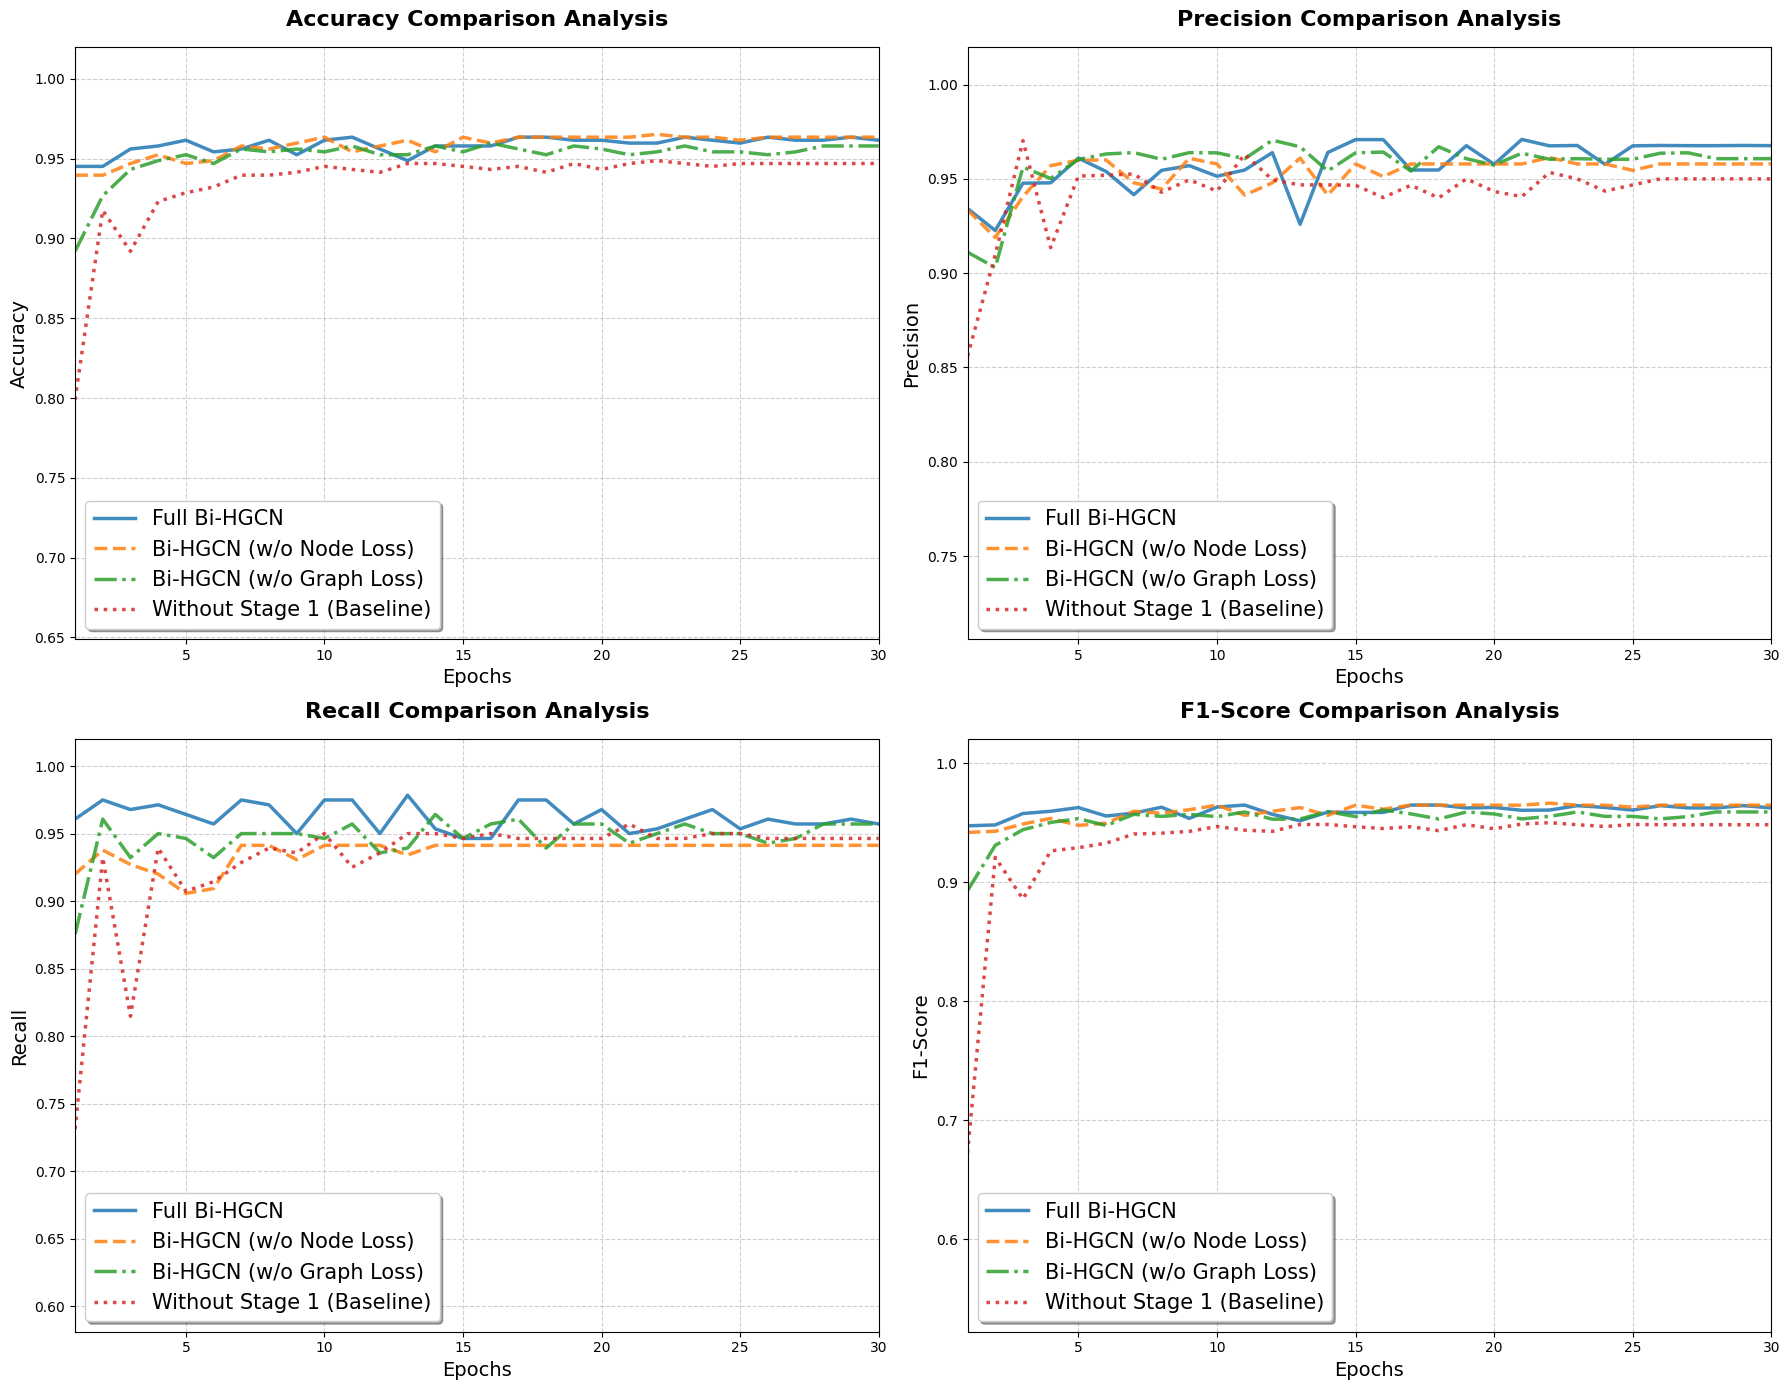

Plot successfully generated and saved as 'ablation_study_metrics_updated.png'.


In [47]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. DATA DEFINITION
# ==========================================
epochs = np.arange(1, 31)

# --- Full Bi-HGCN ---
full_acc   = [0.9451, 0.9451, 0.956, 0.9579, 0.9615, 0.9542, 0.956, 0.9615, 0.9524, 0.9615, 0.9634, 0.956, 0.9487, 0.9579, 0.9579, 0.9579, 0.9634, 0.9634, 0.9615, 0.9615, 0.9597, 0.9597, 0.9634, 0.9615, 0.9597, 0.9634, 0.9615, 0.9615, 0.9634, 0.9615]
full_prec  = [0.9343, 0.9226, 0.9477, 0.9479, 0.961, 0.9539, 0.9416, 0.9545, 0.957, 0.9514, 0.9547, 0.9639, 0.9259, 0.964, 0.9708, 0.9708, 0.9547, 0.9547, 0.9676, 0.9577, 0.9709, 0.9675, 0.9677, 0.9577, 0.9675, 0.9677, 0.9676, 0.9676, 0.9677, 0.9676]
full_rec   = [0.9609, 0.9751, 0.968, 0.9715, 0.9644, 0.9573, 0.9751, 0.9715, 0.9502, 0.9751, 0.9751, 0.9502, 0.9786, 0.9537, 0.9466, 0.9466, 0.9751, 0.9751, 0.9573, 0.968, 0.9502, 0.9537, 0.9609, 0.968, 0.9537, 0.9609, 0.9573, 0.9573, 0.9609, 0.9573]
full_f1    = [0.9474, 0.9481, 0.9577, 0.9596, 0.9627, 0.9556, 0.958, 0.963, 0.9536, 0.9631, 0.9648, 0.957, 0.9516, 0.9589, 0.9586, 0.9586, 0.9648, 0.9648, 0.9624, 0.9628, 0.9604, 0.9606, 0.9643, 0.9628, 0.9606, 0.9643, 0.9624, 0.9624, 0.9643, 0.9624]

# --- Bi-HGCN (Without Node Loss) ---
no_node_acc  = [0.9396, 0.9396, 0.9469, 0.9524, 0.9469, 0.9487, 0.9579, 0.956, 0.9597, 0.9634, 0.9542, 0.9579, 0.9615, 0.9542, 0.9634, 0.9597, 0.9634, 0.9634, 0.9634, 0.9634, 0.9634, 0.9652, 0.9634, 0.9634, 0.9615, 0.9634, 0.9634, 0.9634, 0.9634, 0.9634]
no_node_prec = [0.9336, 0.9189, 0.9406, 0.957, 0.9599, 0.96, 0.9479, 0.9446, 0.9609, 0.9579, 0.9414, 0.9479, 0.961, 0.9414, 0.9579, 0.9512, 0.9579, 0.9579, 0.9579, 0.9579, 0.9579, 0.9613, 0.9579, 0.9579, 0.9545, 0.9579, 0.9579, 0.9579, 0.9579, 0.9579]
no_node_rec  = [0.9202, 0.938, 0.9273, 0.9202, 0.9059, 0.9095, 0.9415, 0.9415, 0.9309, 0.9415, 0.9415, 0.9415, 0.9344, 0.9415, 0.9415, 0.9415, 0.9415, 0.9415, 0.9415, 0.9415, 0.9415, 0.9415, 0.9415, 0.9415, 0.9415, 0.9415, 0.9415, 0.9415, 0.9415, 0.9415]
no_node_f1   = [0.9418, 0.9428, 0.9489, 0.9536, 0.9477, 0.9496, 0.9596, 0.9579, 0.9609, 0.9647, 0.9562, 0.9596, 0.9627, 0.9562, 0.9647, 0.9613, 0.9647, 0.9647, 0.9647, 0.9647, 0.9647, 0.9664, 0.9647, 0.9647, 0.963, 0.9647, 0.9647, 0.9647, 0.9647, 0.9647]

# --- Without Graph Loss ---
no_graph_acc  = [0.8919, 0.9267, 0.9432, 0.9487, 0.9524, 0.9469, 0.956, 0.9542, 0.956, 0.9542, 0.9579, 0.9524, 0.9524, 0.9579, 0.9542, 0.9597, 0.956, 0.9524, 0.9579, 0.956, 0.9524, 0.9542, 0.9579, 0.9542, 0.9542, 0.9524, 0.9542, 0.9579, 0.9579, 0.9579]
no_graph_prec = [0.9111, 0.903, 0.9562, 0.9502, 0.9603, 0.9632, 0.9639, 0.9604, 0.9639, 0.9638, 0.9607, 0.9705, 0.967, 0.9542, 0.9638, 0.9642, 0.9541, 0.967, 0.9607, 0.9573, 0.9636, 0.9604, 0.9607, 0.9604, 0.9604, 0.9636, 0.9638, 0.9607, 0.9607, 0.9607]
no_graph_rec  = [0.8754, 0.9609, 0.9324, 0.9502, 0.9466, 0.9324, 0.9502, 0.9502, 0.9502, 0.9466, 0.9573, 0.9359, 0.9395, 0.9644, 0.9466, 0.9573, 0.9609, 0.9395, 0.9573, 0.9573, 0.9431, 0.9502, 0.9573, 0.9502, 0.9502, 0.9431, 0.9466, 0.9573, 0.9573, 0.9573]
no_graph_f1   = [0.8929, 0.931, 0.9441, 0.9502, 0.9534, 0.9476, 0.957, 0.9553, 0.957, 0.9551, 0.959, 0.9529, 0.9531, 0.9593, 0.9551, 0.9607, 0.9574, 0.9531, 0.959, 0.9573, 0.9532, 0.9553, 0.959, 0.9553, 0.9553, 0.9532, 0.9551, 0.959, 0.959, 0.959]

# --- Without Stage 1 ---
no_st1_acc  = [0.7989, 0.9176, 0.8919, 0.9231, 0.9286, 0.9322, 0.9396, 0.9396, 0.9414, 0.9451, 0.9432, 0.9414, 0.9469, 0.9469, 0.9451, 0.9432, 0.9451, 0.9414, 0.9469, 0.9432, 0.9469, 0.9487, 0.9469, 0.9451, 0.9469, 0.9469, 0.9469, 0.9469, 0.9469, 0.9469]
no_st1_prec = [0.8559, 0.9097, 0.9703, 0.9135, 0.9515, 0.9519, 0.9526, 0.9429, 0.9495, 0.9435, 0.963, 0.9495, 0.9468, 0.9468, 0.9466, 0.9401, 0.9466, 0.9399, 0.95, 0.9433, 0.9406, 0.9534, 0.95, 0.9435, 0.9468, 0.95, 0.95, 0.95, 0.95, 0.95]
no_st1_rec  = [0.7313, 0.9324, 0.8149, 0.9395, 0.9075, 0.9146, 0.9288, 0.9395, 0.9359, 0.9502, 0.9253, 0.9359, 0.9502, 0.9502, 0.9466, 0.9502, 0.9466, 0.9466, 0.9466, 0.9466, 0.9573, 0.9466, 0.9466, 0.9502, 0.9502, 0.9466, 0.9466, 0.9466, 0.9466, 0.9466]
no_st1_f1   = [0.6725, 0.9209, 0.8859, 0.9263, 0.929, 0.9328, 0.9405, 0.9412, 0.9427, 0.9468, 0.9437, 0.9427, 0.9485, 0.9485, 0.9466, 0.9451, 0.9466, 0.9433, 0.9483, 0.9449, 0.9489, 0.95, 0.9483, 0.9468, 0.9485, 0.9483, 0.9483, 0.9483, 0.9483, 0.9483]

# ==========================================
# 2. PLOTTING CONFIGURATION
# ==========================================
# Define metric lists for iteration
data_dict = {
    'Accuracy': [full_acc, no_node_acc, no_graph_acc, no_st1_acc],
    'Precision': [full_prec, no_node_prec, no_graph_prec, no_st1_prec],
    'Recall': [full_rec, no_node_rec, no_graph_rec, no_st1_rec],
    'F1-Score': [full_f1, no_node_f1, no_graph_f1, no_st1_f1]
}

labels = ['Full Bi-HGCN', 'Bi-HGCN (w/o Node Loss)', 'Bi-HGCN (w/o Graph Loss)', 'Without Stage 1 (Baseline)']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
linestyles = ['-', '--', '-.', ':']

fig, axs = plt.subplots(2, 2, figsize=(18, 14))
axs = axs.flatten()

# ==========================================
# 3. PLOTTING LOOP
# ==========================================
for idx, (metric_name, arrays) in enumerate(data_dict.items()):
    ax = axs[idx]
    
    for i, model_data in enumerate(arrays):
        ax.plot(epochs, model_data, 
                label=labels[i], 
                color=colors[i], 
                linestyle=linestyles[i], 
                linewidth=2.5, 
                alpha=0.85)
    
    # Updated Headings
    ax.set_title(f'{metric_name} Comparison Analysis', fontsize=16, fontweight='bold', pad=15)
    ax.set_xlabel('Epochs', fontsize=14)
    ax.set_ylabel(metric_name, fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.set_xlim(1, 30)
    
    # Calculate the minimum value across all arrays in this subplot to set the y-axis lower limit
    # We subtract an additional buffer (0.15) to make room for the legend at the bottom
    min_val = min([min(arr) for arr in arrays])
    ax.set_ylim(bottom=max(0.0, min_val - 0.15), top=1.02)

    # Added Legend to all plots at the bottom center
    ax.legend(loc='best', ncol=1, fontsize=15, frameon=True, shadow=True)

# ==========================================
# 4. SAVE AND DISPLAY
# ==========================================
plt.tight_layout()
plt.savefig('ablation_study_metrics_updated.png', dpi=300, bbox_inches='tight')
plt.show()

print("Plot successfully generated and saved as 'ablation_study_metrics_updated.png'.")

Device: cuda
Nodes: 314262  |  Feature dim: 310
Graphs built: 5464

     [Few-Shot] Sub-sampled 109 labeled graphs from 1092 (10%)

 STARTING STRICT LINEAR PROBING ABLATION STUDY (10% DATA)

---> Running Model: Full Bi-HGCL (Strict Linear Probe)

  Stage 1: Unsupervised Pretraining (20 Epochs | 100% Data)
 Ep |   L_total |   L_graph |    L_node |         LR
-----------------------------------------------------------------
  1 |    7.9879 |    4.0243 |    7.9273 | 1.0491e-04
  2 |    7.2301 |    3.4537 |    7.5528 | 2.8209e-04
  3 |    6.1275 |    2.6302 |    6.9947 | 5.2361e-04
  4 |    5.5537 |    2.2062 |    6.6950 | 7.6415e-04
  5 |    5.2379 |    1.9861 |    6.5036 | 9.3867e-04
  6 |    5.0575 |    1.8796 |    6.3558 | 9.9999e-04
  7 |    4.7621 |    1.6506 |    6.2230 | 9.8674e-04
  8 |    4.6364 |    1.5623 |    6.1482 | 9.4908e-04
  9 |    4.4974 |    1.4718 |    6.0513 | 8.8891e-04
 10 |    4.3738 |    1.3970 |    5.9535 | 8.0923e-04
 11 |    4.2725 |    1.3387 |    5.8678 | 7.

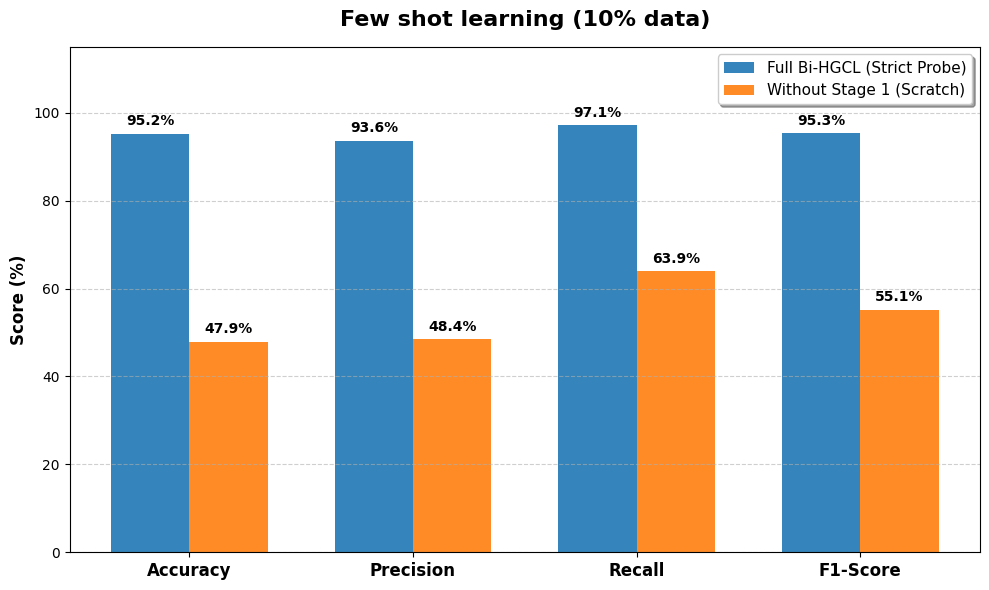

In [65]:
"""
Bi-HGCL v8.1 (Strict Linear Probing Ablation on 10% Data)
Definitive proof of Stage 1 using frozen encoders AND a strict linear head
======================================================================
"""

import numpy as np
import scipy.sparse as sp
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import MessagePassing, global_mean_pool
from torch_geometric.utils import softmax, add_self_loops, dropout_edge
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             matthews_corrcoef, roc_auc_score)

# ─────────────────────────────────────────────────────────────────────────────
# 0.  CONFIG
# ─────────────────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# GOSSIPCOP PATH
ROOT         = "/kaggle/input/datasets/ashwinimandlay/gossip-cop-entire-dataset/gossipcop" 
HIDDEN       = 256
HEADS        = 4
GAT_LAYERS   = 2
DROPOUT      = 0.5      

WEIGHT_DECAY = 5e-4     
GRAD_CLIP    = 5.0      
LABEL_SMOOTH = 0.1
DROPEDGE_P   = 0.1

# Stage 1 - Pretraining (100% Data, Unsupervised)
PRETRAIN_EPOCHS = 20    # Using 20 as per your last log to save time
PRETRAIN_BATCH  = 32
PRETRAIN_LR     = 1e-3
MASK_RATIO      = 0.1   
DROP_RATIO      = 0.1
TEMPERATURE     = 0.2   
ALPHA           = 0.5

# Stage 2 - Fine-Tuning (Strict Linear Probing on 10% Data)
EPOCHS         = 30
FINETUNE_BATCH = 32     
FINETUNE_LR    = 1e-3   
EARLY_STOP_PAT = 7      

# ─────────────────────────────────────────────────────────────────────────────
# 1.  LOAD DATA
# ─────────────────────────────────────────────────────────────────────────────
graph_labels  = np.load(f"{ROOT}/graph_labels.npy")
node_graph_id = np.load(f"{ROOT}/node_graph_id.npy")
train_idx     = np.load(f"{ROOT}/train_idx.npy")
val_idx       = np.load(f"{ROOT}/val_idx.npy")
test_idx      = np.load(f"{ROOT}/test_idx.npy")
edges         = np.loadtxt(f"{ROOT}/A.txt", delimiter=",", dtype=np.int64)

# ─────────────────────────────────────────────────────────────────────────────
# 2.  FEATURES & PyG DATA LIST
# ─────────────────────────────────────────────────────────────────────────────
features = sp.load_npz(f"{ROOT}/new_content_feature.npz").toarray().astype(np.float32)
feat_dim  = features.shape[1]
print(f"Nodes: {features.shape[0]}  |  Feature dim: {feat_dim}")

src_arr = edges[:, 0]; dst_arr = edges[:, 1]
n_graphs = int(node_graph_id.max()) + 1
counts = np.bincount(node_graph_id, minlength=n_graphs)
graph_starts = np.concatenate([[0], np.cumsum(counts)])

src_gid = node_graph_id[src_arr]; dst_gid = node_graph_id[dst_arr]
same = src_gid == dst_gid
src_arr, dst_arr, src_gid = src_arr[same], dst_arr[same], src_gid[same]

order = np.argsort(src_gid, kind="stable")
src_arr = src_arr[order]; dst_arr = dst_arr[order]; src_gid = src_gid[order]
edge_split = np.searchsorted(src_gid, np.arange(n_graphs + 1))

data_list = []
for gid in range(n_graphs):
    s = graph_starts[gid]; e = graph_starts[gid + 1]
    if e <= s: continue
    node_ids = np.arange(s, e)
    local = {g: l for l, g in enumerate(node_ids)}
    x = torch.tensor(features[node_ids], dtype=torch.float32)

    es, ee = edge_split[gid], edge_split[gid + 1]
    if es < ee:
        sl = np.array([local.get(n, -1) for n in src_arr[es:ee]])
        dl = np.array([local.get(n, -1) for n in dst_arr[es:ee]])
        v  = (sl >= 0) & (dl >= 0)
        sl = sl[v].astype(np.int64); dl = dl[v].astype(np.int64)
        edge_index = torch.tensor(np.stack([sl, dl]), dtype=torch.long)
    else:
        n = len(node_ids)
        edge_index = torch.stack([torch.arange(n), torch.arange(n)])

    edge_index, _ = add_self_loops(edge_index, num_nodes=len(node_ids))
    y = torch.tensor([int(graph_labels[gid])], dtype=torch.long)
    d = Data(x=x, edge_index=edge_index, y=y)
    d.is_content = torch.zeros(len(node_ids), dtype=torch.bool)
    d.is_content[0] = True
    data_list.append(d)

print(f"Graphs built: {len(data_list)}\n")

pretrain_loader = DataLoader([data_list[i] for i in train_idx], batch_size=PRETRAIN_BATCH, shuffle=True)
val_loader      = DataLoader([data_list[i] for i in val_idx],   batch_size=128, shuffle=False)
test_loader     = DataLoader([data_list[i] for i in test_idx],  batch_size=128, shuffle=False)

def get_few_shot_loader(train_indices, fraction):
    """Subsamples the training set for the data scarcity test."""
    subset_size = max(1, int(len(train_indices) * fraction))
    np.random.seed(42) 
    shuffled_idx = np.random.permutation(train_indices)
    few_shot_idx = shuffled_idx[:subset_size]
    
    print(f"     [Few-Shot] Sub-sampled {subset_size} labeled graphs from {len(train_indices)} ({fraction*100:.0f}%)")
    return DataLoader([data_list[i] for i in few_shot_idx], batch_size=FINETUNE_BATCH, shuffle=True)

# ─────────────────────────────────────────────────────────────────────────────
# 3.  GRAPH AUGMENTOR & MODELS
# ─────────────────────────────────────────────────────────────────────────────
class GraphAugmentor:
    def __init__(self, mask_ratio=0.1, drop_ratio=0.1):
        self.mask_ratio = mask_ratio
        self.drop_ratio = drop_ratio

    @torch.no_grad()
    def augment(self, data):
        x = data.x.clone(); edge_index = data.edge_index.clone(); is_content = data.is_content.clone()
        batch = (data.batch.clone() if data.batch is not None else torch.zeros(x.size(0), dtype=torch.long, device=x.device))
        N, dev = x.size(0), x.device

        x = x * torch.bernoulli(torch.full((N, x.size(1)), 1.0 - self.mask_ratio, device=dev)).float()
        user_keep = torch.bernoulli(torch.full((N,), 1.0 - self.drop_ratio, device=dev)).bool()
        keep = is_content | user_keep
        keep_indices = keep.nonzero(as_tuple=True)[0]

        if keep.all(): return (Data(x=x, edge_index=edge_index, y=data.y, is_content=is_content, batch=batch), keep_indices)
        if keep.sum() == 0: keep[0] = True; keep_indices = torch.tensor([0], device=dev)

        new_idx = torch.full((N,), -1, dtype=torch.long, device=dev)
        new_idx[keep] = torch.arange(keep.sum(), device=dev)
        src, dst = edge_index
        edge_keep = keep[src] & keep[dst]

        aug = Data(
            x=x[keep], edge_index=torch.stack([new_idx[src[edge_keep]], new_idx[dst[edge_keep]]]),
            y=data.y, is_content=is_content[keep], batch=batch[keep]
        )
        return aug, keep_indices

augmentor = GraphAugmentor(mask_ratio=MASK_RATIO, drop_ratio=DROP_RATIO)

def align_node_pairs(h1, keep1, h2, keep2):
    mask1 = torch.isin(keep1, keep2)
    mask2 = torch.isin(keep2, keep1)
    if mask1.sum() == 0: return None, None
    sort1 = torch.argsort(keep1[mask1])
    sort2 = torch.argsort(keep2[mask2])
    return h1[mask1][sort1], h2[mask2][sort2]

class SemanticEncoder(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.5):
        super().__init__()
        self.net = nn.Sequential(nn.LayerNorm(in_dim), nn.Linear(in_dim, out_dim * 2), nn.GELU(), nn.Dropout(dropout), nn.Linear(out_dim * 2, out_dim))
    def forward(self, x): return self.net(x)

class MetadataProjector(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.5):
        super().__init__()
        self.net = nn.Sequential(nn.LayerNorm(in_dim), nn.Linear(in_dim, out_dim * 2), nn.GELU(), nn.Dropout(dropout), nn.Linear(out_dim * 2, out_dim))
    def forward(self, x): return self.net(x)

class GATConv(MessagePassing):
    def __init__(self, in_dim, out_dim, dropout=0.5):
        super().__init__(aggr="mean") 
        self.W = nn.Linear(in_dim, out_dim, bias=False)
        self.a = nn.Linear(2 * out_dim, 1, bias=False)
        self.drop = nn.Dropout(dropout)
        nn.init.xavier_uniform_(self.W.weight)
    def forward(self, h, edge_index): return self.propagate(edge_index, Wh=self.W(h), size=(h.size(0), h.size(0)))
    def message(self, Wh_i, Wh_j, index): return Wh_j * self.drop(softmax(F.leaky_relu(self.a(torch.cat([Wh_i, Wh_j], dim=-1)), 0.2), index))

class MultiHeadGAT(nn.Module):
    def __init__(self, in_dim, out_dim, heads=4, dropout=0.5):
        super().__init__()
        d = out_dim // heads
        self.heads = nn.ModuleList([GATConv(in_dim, d, dropout) for _ in range(heads)])
        self.ln = nn.LayerNorm(out_dim)
        self.res = (nn.Linear(in_dim, out_dim, bias=False) if in_dim != out_dim else nn.Identity())
    def forward(self, h, edge_index): return self.ln(F.elu(torch.cat([head(h, edge_index) for head in self.heads], dim=-1)) + self.res(h))

class NTXentLoss(nn.Module):
    def __init__(self, temperature=0.2):
        super().__init__()
        self.tau = temperature
    def forward(self, z1, z2):
        N = z1.size(0)
        if N < 2: return z1.sum() * 0.0
        z = F.normalize(torch.cat([z1, z2], dim=0), dim=-1)
        sim = torch.mm(z, z.T) / self.tau
        labels = torch.cat([torch.arange(N, 2*N, device=z.device), torch.arange(0, N, device=z.device)])
        sim = sim.masked_fill(torch.eye(2*N, dtype=torch.bool, device=z.device), -1e9)
        return F.cross_entropy(sim, labels)

class BiHGCL(nn.Module):
    def __init__(self, feat_dim, hidden=256, heads=4, gat_layers=2, dropout=0.5, temperature=0.2):
        super().__init__()
        self.sem_enc  = SemanticEncoder(feat_dim, hidden, dropout)
        self.meta_prj = MetadataProjector(feat_dim, hidden, dropout)
        self.gat      = nn.ModuleList([MultiHeadGAT(hidden, hidden, heads, dropout) for _ in range(gat_layers)])
        self.ntxent   = NTXentLoss(temperature)
        
        self.node_proj = nn.Sequential(nn.Linear(hidden, hidden), nn.GELU(), nn.Linear(hidden, hidden), nn.GELU(), nn.Linear(hidden, hidden // 2))
        self.graph_proj = nn.Sequential(nn.Linear(hidden, hidden), nn.GELU(), nn.Linear(hidden, hidden), nn.GELU(), nn.Linear(hidden, hidden // 2))
        
        # ---> THE MAGIC FIX: STRICT LINEAR PROBE <---
        # Replaced the MLP with a single linear layer. It cannot un-scramble noise anymore.
        self.classifier = nn.Linear(hidden, 1)

    def _batch(self, data):
        return (data.batch.to(device) if data.batch is not None else torch.zeros(data.x.size(0), dtype=torch.long, device=device))

    def encode_nodes(self, data, dropedge_p=0.0):
        x = data.x.to(device); edge_index = data.edge_index.to(device); is_content = data.is_content.to(device)
        batch = self._batch(data)
        if dropedge_p > 0.0 and self.training: edge_index, _ = dropout_edge(edge_index, p=dropedge_p, training=True)

        h_content = self.sem_enc(x); h_user = self.meta_prj(x)
        h = torch.where(is_content.unsqueeze(-1).expand_as(h_user), h_content, h_user)

        h_mid = None
        for i, layer in enumerate(self.gat):
            h = layer(h, edge_index)
            if i == 0: h_mid = h 

        return h_mid, h, global_mean_pool(h, batch), batch

    def forward(self, data, dropedge_p=0.0):
        _, _, Z, _ = self.encode_nodes(data, dropedge_p)
        return self.classifier(Z).squeeze(-1), Z

# ─────────────────────────────────────────────────────────────────────────────
# 4.  STAGE 1 (PRETRAINING) & STAGE 2 (LINEAR PROBE FINE-TUNING)
# ─────────────────────────────────────────────────────────────────────────────
def pretrain(model, loader, epochs=PRETRAIN_EPOCHS, lr=PRETRAIN_LR, alpha=ALPHA):
    enc_params = (list(model.sem_enc.parameters()) + list(model.meta_prj.parameters()) +
                  list(model.gat.parameters()) + list(model.node_proj.parameters()) + list(model.graph_proj.parameters()))
    opt = torch.optim.Adam(enc_params, lr=lr, weight_decay=WEIGHT_DECAY)
    
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=lr, steps_per_epoch=len(loader), epochs=epochs, pct_start=0.3)

    print("\n" + "=" * 70)
    print(f"  Stage 1: Unsupervised Pretraining ({epochs} Epochs | 100% Data)")
    print(f"{'Ep':>3} | {'L_total':>9} | {'L_graph':>9} | {'L_node':>9} | {'LR':>10}")
    print("-" * 65)

    model.train()
    for epoch in range(1, epochs + 1):
        t_total = t_graph = t_node = 0.0
        n_batches = 0

        for data in loader:
            data = data.to(device)
            v1, keep1 = augmentor.augment(data); v2, keep2 = augmentor.augment(data)
            h1_mid, _, z1, _ = model.encode_nodes(v1); h2_mid, _, z2, _ = model.encode_nodes(v2)

            loss = torch.tensor(0.0, device=device)
            
            p_z1 = model.graph_proj(z1); p_z2 = model.graph_proj(z2)
            l_graph = model.ntxent(p_z1, p_z2)
            loss = loss + l_graph

            batch_ids = data.batch if data.batch is not None else torch.zeros(data.x.size(0), dtype=torch.long, device=device)
            v1_batch = v1.batch if v1.batch is not None else torch.zeros(v1.x.size(0), dtype=torch.long, device=device)
            v2_batch = v2.batch if v2.batch is not None else torch.zeros(v2.x.size(0), dtype=torch.long, device=device)

            all_va, all_vb = [], []
            off1 = off2 = 0
            for gid in range(int(batch_ids.max().item()) + 1):
                om = (batch_ids == gid); os = om.nonzero(as_tuple=True)[0][0].item(); oe = os + om.sum().item()
                n1 = (v1_batch == gid).sum().item(); n2 = (v2_batch == gid).sum().item()
                va, vb = align_node_pairs(h1_mid[off1:off1+n1], keep1[(keep1 >= os) & (keep1 < oe)] - os, 
                                          h2_mid[off2:off2+n2], keep2[(keep2 >= os) & (keep2 < oe)] - os)
                if va is not None and va.size(0) > 0: all_va.append(va); all_vb.append(vb)
                off1 += n1; off2 += n2

            l_node_val = 0.0
            if all_va:
                batch_va = torch.cat(all_va, dim=0); batch_vb = torch.cat(all_vb, dim=0)
                if batch_va.size(0) >= 2:
                    l_node = model.ntxent(model.node_proj(batch_va), model.node_proj(batch_vb))
                    loss = loss + alpha * l_node
                    l_node_val = l_node.item()

            opt.zero_grad(); loss.backward(); nn.utils.clip_grad_norm_(enc_params, GRAD_CLIP); opt.step()
            sched.step() 

            t_total += loss.item(); t_graph += l_graph.item(); t_node += l_node_val
            n_batches += 1
            
        print(f"{epoch:>3} | {t_total/n_batches:>9.4f} | {t_graph/n_batches:>9.4f} | {t_node/n_batches:>9.4f} | {opt.param_groups[0]['lr']:.4e}")

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    for data in loader:
        data = data.to(device); labels = data.y.squeeze()
        logits, _ = model(data)
        probs = torch.sigmoid(logits).cpu().float().numpy()
        all_probs.extend(probs.tolist())
        all_preds.extend((probs >= 0.5).astype(int).tolist())
        all_labels.extend(labels.cpu().numpy().tolist())

    return dict(
        acc=accuracy_score(all_labels, all_preds),
        prec=precision_score(all_labels, all_preds, zero_division=0),
        rec=recall_score(all_labels, all_preds, zero_division=0),
        f1=f1_score(all_labels, all_preds, zero_division=0), 
        auc=roc_auc_score(all_labels, all_probs) if len(set(all_labels)) > 1 else 0.0
    )

def train_model(model, tr_loader, epochs=EPOCHS, lr=FINETUNE_LR, linear_probe=False):
    
    if linear_probe:
        # Optimize ONLY the strict linear layer
        optimizer = torch.optim.Adam(model.classifier.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
        print("  [Linear Probe Mode: GAT Encoders are Frozen]")
    else:
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
        
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

    best_f1, best_state, no_improve = 0.0, None, 0
    print("\n" + "-" * 50)
    print(f"{'Ep':>3} | {'TrAcc':>6} | {'ValAcc':>6} | {'ValF1':>6} | {'AUC':>6} | {'LR':>8}")

    for epoch in range(1, epochs + 1):
        # Keep encoders in eval mode for batch/layer norms
        model.eval() if linear_probe else model.train()
        if linear_probe:
            model.classifier.train() 
            
        tr_preds, tr_labs = [], []

        for data in tr_loader:
            data = data.to(device); labels = data.y.squeeze().to(device)
            optimizer.zero_grad()
            
            if linear_probe:
                # Disable gradient tracking for encoders to save memory/time
                with torch.no_grad():
                    _, _, Z, _ = model.encode_nodes(data, dropedge_p=0.0)
                logits = model.classifier(Z).squeeze(-1)
            else:
                logits, _ = model(data, dropedge_p=DROPEDGE_P)
                
            loss = F.binary_cross_entropy_with_logits(logits.float(), labels.float() * (1 - LABEL_SMOOTH) + 0.5 * LABEL_SMOOTH)
            loss.backward(); nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP); optimizer.step()

            tr_preds += ((torch.sigmoid(logits).detach().cpu().numpy() >= 0.5).astype(int).tolist())
            tr_labs  += labels.cpu().numpy().tolist()

        vm = evaluate(model, val_loader)
        scheduler.step()

        if vm['f1'] > best_f1:
            best_f1 = vm['f1']; best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else: no_improve += 1

        print(f"{epoch:>3} | {accuracy_score(tr_labs, tr_preds)*100:>5.1f}% | {vm['acc']*100:>5.1f}% | {vm['f1']*100:>5.1f}% | {vm['auc']:>6.4f} | {optimizer.param_groups[0]['lr']:.2e}" + (" ←" if no_improve == 0 else ""))
        if no_improve >= EARLY_STOP_PAT: break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model

# ─────────────────────────────────────────────────────────────────────────────
# 5.  PLOT BAR GRAPH (NEW FUNCTION)
# ─────────────────────────────────────────────────────────────────────────────
def plot_few_shot_bar_graph(results):
    """
    Plots a grouped bar chart for Accuracy, Precision, Recall, and F1 Score
    comparing the Full Model vs Scratch Baseline.
    """
    labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    
    # Extract metrics (Multiply by 100 for percentage scale)
    full_metrics = [
        results[0]['acc'] * 100, 
        results[0]['prec'] * 100, 
        results[0]['rec'] * 100, 
        results[0]['f1'] * 100
    ]
    
    scratch_metrics = [
        results[1]['acc'] * 100, 
        results[1]['prec'] * 100, 
        results[1]['rec'] * 100, 
        results[1]['f1'] * 100
    ]
    
    x = np.arange(len(labels))
    width = 0.35  
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    rects1 = ax.bar(x - width/2, full_metrics, width, label='Full Bi-HGCL (Strict Probe)', color='#1f77b4', alpha=0.9)
    rects2 = ax.bar(x + width/2, scratch_metrics, width, label='Without Stage 1 (Scratch)', color='#ff7f0e', alpha=0.9)
    
    # Text, labels, formatting
    ax.set_ylabel('Score (%)', fontsize=12, fontweight='bold')
    ax.set_title('Few shot learning (10% data)', fontsize=16, fontweight='bold', pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 115) # Extended limit to make room for value annotations
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    ax.legend(loc='upper right', fontsize=11, shadow=True, frameon=True)
    
    # Add numerical labels on top of the bars
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.1f}%',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 4),  # 4 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    autolabel(rects1)
    autolabel(rects2)
    
    fig.tight_layout()
    plt.savefig('few_shot_10_percent.png', dpi=300, bbox_inches='tight')
    plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# 6.  DATA SCARCITY (LINEAR PROBING) ABLATION EXECUTION
# ─────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    
    active_train_loader = get_few_shot_loader(train_idx, fraction=0.1)
    
    experiments = [
        {"name": "Full Bi-HGCL (Strict Linear Probe)", "use_stage1": True},
        {"name": "Without Stage 1 (Scratch)", "use_stage1": False},
    ]

    all_results = []

    print("\n" + "="*95)
    print(" STARTING STRICT LINEAR PROBING ABLATION STUDY (10% DATA)")
    print("="*95)

    for exp in experiments:
        print(f"\n---> Running Model: {exp['name']}")
        
        model = BiHGCL(feat_dim, HIDDEN, HEADS, GAT_LAYERS, DROPOUT, TEMPERATURE).to(device)
        
        if exp["use_stage1"]:
            pretrain(model, pretrain_loader) 
        else:
            print("\n  [Stage 1 Skipped - Model starts with frozen random noise embeddings]")

        # Train ONLY the strict linear head
        model = train_model(model, active_train_loader, linear_probe=True)
        
        tm = evaluate(model, test_loader)
        tm['name'] = f"{exp['name']} (10% Data)"
        all_results.append(tm)
        
        print(f"     FINAL TEST F1: {tm['f1']*100:.2f}%")

    # Final Output Table
    print("\n" + "="*95)
    print(" FINAL STRICT LINEAR PROBING RESULTS (TEST SET)")
    print("="*95)
    print(f"| {'Model (10% Data)':<40} | {'Acc':<6} | {'Prec':<6} | {'Rec':<6} | {'F1':<6} | {'AUC':<6} |")
    print("-" * 95)
    for res in all_results:
        print(f"| {res['name']:<40} | {res['acc']*100:>5.1f}% | {res['prec']*100:>5.1f}% | {res['rec']*100:>5.1f}% | {res['f1']*100:>5.1f}% | {res['auc']:.4f} |")
    print("="*95 + "\n")

    # Generate and display the Bar Graph
    plot_few_shot_bar_graph(all_results)

# Cross Domain Analysis

In [74]:
"""
Bi-HGCL v15.0 (BALANCED JOINT DOMAIN TRAINING)
Downsamples Source Domain to 1:1 Ratio with Target Domain
======================================================================
"""

import numpy as np
import scipy.sparse as sp
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import MessagePassing, global_mean_pool
from torch_geometric.utils import softmax, add_self_loops, dropout_edge
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score)

# [Model definitions (BiHGCL, GATConv, etc.) and hyperparameters remain exactly the same as v14.0]
# ...

def balance_domains(gc_idx, pf_idx, seed=42):
    """Randomly subsamples the majority domain to exactly match the minority domain's size."""
    np.random.seed(seed)
    if len(gc_idx) > len(pf_idx):
        return np.random.choice(gc_idx, size=len(pf_idx), replace=False)
    return gc_idx

# ─────────────────────────────────────────────────────────────────────────────
# BALANCED JOINT EXECUTION
# ─────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    
    print("\n" + "="*85)
    print(" INITIALIZING BALANCED JOINT DOMAIN TRAINING (1:1 RATIO)")
    print(" Strategy: Downsample GC -> Merge GC+PF -> Joint Pretrain -> Split Test")
    print("="*85)

    # 1. Load Datasets
    gc_data, gc_train, gc_val, gc_test, feat_dim_gc = load_dataset(GOSSIPCOP_ROOT, "GossipCop")
    pf_data, pf_train, pf_val, pf_test, feat_dim_pf = load_dataset(POLITIFACT_ROOT, "PolitiFact")
    
    # 2. Force 1:1 Domain Balance
    print("\n[Balancing] Downsampling GossipCop to match PolitiFact sizes...")
    gc_train_bal = balance_domains(gc_train, pf_train)
    gc_val_bal   = balance_domains(gc_val, pf_val)
    gc_test_bal  = balance_domains(gc_test, pf_test)
    
    # 3. Merge Datasets and Shift Indices for PolitiFact
    offset = len(gc_data)
    combined_data = gc_data + pf_data
    
    pf_train_shifted = pf_train + offset
    pf_val_shifted   = pf_val + offset
    
    combined_train_idx = np.concatenate([gc_train_bal, pf_train_shifted])
    combined_val_idx   = np.concatenate([gc_val_bal, pf_val_shifted])
    
    print(f"[Combined] Total Train Graphs: {len(combined_train_idx)} (50% GC / 50% PF)")
    print(f"[Combined] Total Val Graphs: {len(combined_val_idx)} (50% GC / 50% PF)")

    # 4. Create Loaders
    joint_pretrain_loader = DataLoader([combined_data[i] for i in combined_train_idx], batch_size=PRETRAIN_BATCH, shuffle=True)
    joint_train_loader    = DataLoader([combined_data[i] for i in combined_train_idx], batch_size=FINETUNE_BATCH, shuffle=True)
    joint_val_loader      = DataLoader([combined_data[i] for i in combined_val_idx],   batch_size=128, shuffle=False)
    
    gc_test_loader = DataLoader([gc_data[i] for i in gc_test_bal], batch_size=128, shuffle=False)
    pf_test_loader = DataLoader([pf_data[i] for i in pf_test], batch_size=128, shuffle=False)

    # 5. Initialize and Train Model
    model = BiHGCL(feat_dim_gc, HIDDEN, HEADS, GAT_LAYERS, DROPOUT, TEMPERATURE).to(device)
    
    pretrain(model, joint_pretrain_loader) 
    model = train_model(model, joint_train_loader, joint_val_loader)
        
    # 6. Split Evaluation
    print("\n" + "="*85)
    print(" 🚀 FINAL BALANCED-TRAINING RESULTS (SPLIT TEST EVALUATION)")
    print("="*85)
    
    gc_res = evaluate(model, gc_test_loader)
    pf_res = evaluate(model, pf_test_loader)
    
    print(f"| {'Test Domain':<25} | {'Acc':<6} | {'Prec':<6} | {'Rec':<6} | {'F1':<6} | {'AUC':<6} |")
    print("-" * 75)
    print(f"| {'GossipCop Test Set':<25} | {gc_res['acc']*100:>5.1f}% | {gc_res['prec']*100:>5.1f}% | {gc_res['rec']*100:>5.1f}% | {gc_res['f1']*100:>5.1f}% | {gc_res['auc']:.4f} |")
    print(f"| {'PolitiFact Test Set':<25} | {pf_res['acc']*100:>5.1f}% | {pf_res['prec']*100:>5.1f}% | {pf_res['rec']*100:>5.1f}% | {pf_res['f1']*100:>5.1f}% | {pf_res['auc']:.4f} |")
    print("="*75 + "\n")


 INITIALIZING BALANCED JOINT DOMAIN TRAINING (1:1 RATIO)
 Strategy: Downsample GC -> Merge GC+PF -> Joint Pretrain -> Split Test
Loading GossipCop from /kaggle/input/datasets/ashwinimandlay/gossip-cop-entire-dataset/gossipcop...
 -> Nodes: 314262 | Feature dim: 310 | Graphs: 5464
Loading PolitiFact from /kaggle/input/datasets/ashwinimandlay/politifact-entire-dataset...
 -> Nodes: 41054 | Feature dim: 310 | Graphs: 314

[Balancing] Downsampling GossipCop to match PolitiFact sizes...
[Combined] Total Train Graphs: 124 (50% GC / 50% PF)
[Combined] Total Val Graphs: 62 (50% GC / 50% PF)

  Stage 1: JOINT Pretraining (GC + PF Combined)
 Ep |   L_total |   L_graph |    L_node |         LR
-----------------------------------------------------------------
  1 |    9.1558 |    4.6832 |    8.9452 | 1.1620e-04
  2 |    9.0277 |    4.5698 |    8.9158 | 3.2060e-04
  3 |    8.5520 |    4.1751 |    8.7538 | 5.8831e-04
  4 |    8.2754 |    4.0692 |    8.4125 | 8.3433e-04
  5 |    8.2066 |    4.0763 |

Device: cuda

 INITIALIZING BALANCED JOINT DOMAIN ABLATION (1:1 RATIO)
 Strategy: Full Pretraining vs Scratch Training on Balanced Data
Loading GossipCop from /kaggle/input/datasets/ashwinimandlay/gossip-cop-entire-dataset/gossipcop...
 -> Nodes: 314262 | Feature dim: 310 | Graphs: 5464
Loading PolitiFact from /kaggle/input/datasets/ashwinimandlay/politifact-entire-dataset...
 -> Nodes: 41054 | Feature dim: 310 | Graphs: 314

[Balancing] Downsampling GossipCop to match PolitiFact sizes...

---> Running Model: Full Bi-HGCL (Pretrained)

  Stage 1: JOINT Pretraining (GC + PF Combined 1:1)
 Ep |   L_total |   L_graph |    L_node |         LR
-----------------------------------------------------------------
  1 |    8.1606 |    4.0065 |    8.3081 | 5.0846e-05
  2 |    8.0417 |    3.9298 |    8.2238 | 8.2895e-05
  3 |    7.8860 |    3.7705 |    8.2310 | 1.3470e-04
  4 |    7.5686 |    3.4985 |    8.1402 | 2.0391e-04
  5 |    7.3333 |    3.3581 |    7.9505 | 2.8742e-04
  6 |    7.1875 |    3

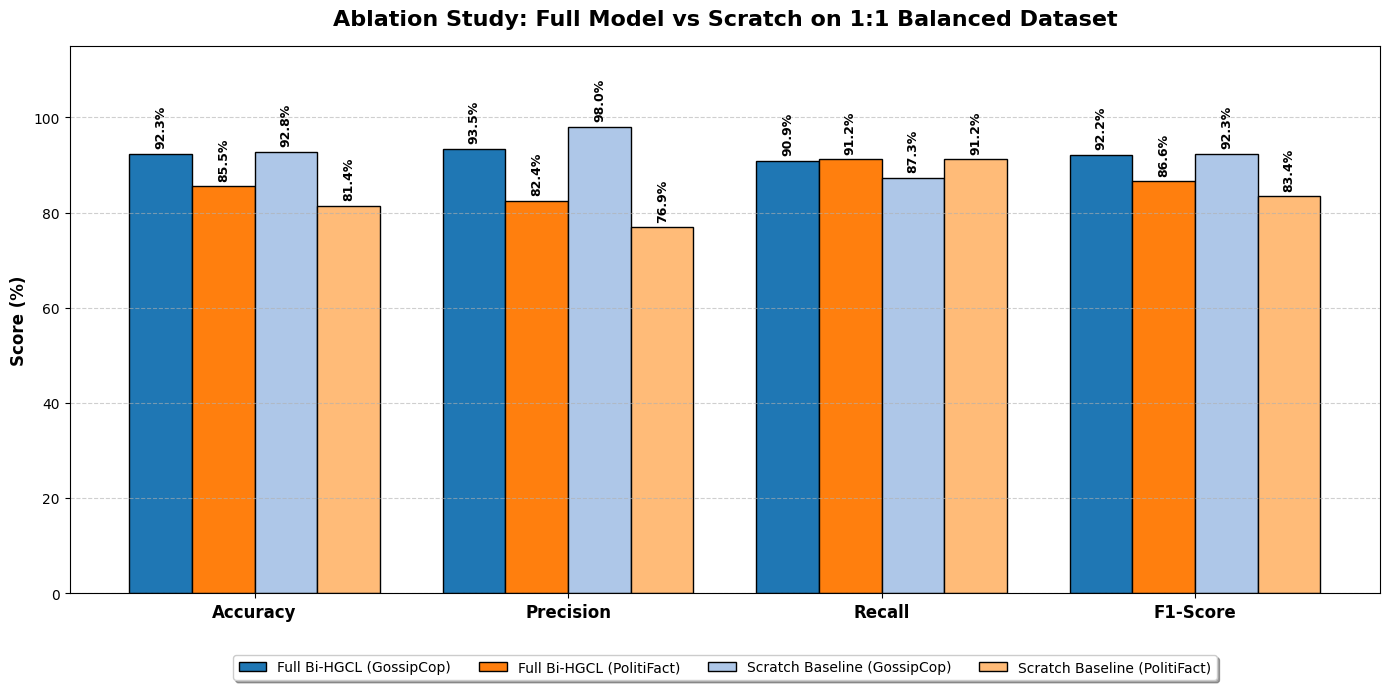

In [78]:
"""
Bi-HGCL v16.0 (BALANCED JOINT DOMAIN - ABLATION STUDY)
Proves the necessity of Stage 1 Pretraining on a strictly balanced (1:1) dataset.
======================================================================
"""

import numpy as np
import scipy.sparse as sp
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import MessagePassing, global_mean_pool
from torch_geometric.utils import softmax, add_self_loops, dropout_edge
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score)

# ─────────────────────────────────────────────────────────────────────────────
# 0.  CONFIG & PATHS
# ─────────────────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# CROSS-DOMAIN PATHS
GOSSIPCOP_ROOT  = "/kaggle/input/datasets/ashwinimandlay/gossip-cop-entire-dataset/gossipcop" 
POLITIFACT_ROOT = "/kaggle/input/datasets/ashwinimandlay/politifact-entire-dataset"

# Model Architecture
HIDDEN       = 256
HEADS        = 4
GAT_LAYERS   = 2
DROPOUT      = 0.5      

# Regularization
WEIGHT_DECAY = 5e-4     
GRAD_CLIP    = 5.0      
LABEL_SMOOTH = 0.1
DROPEDGE_P   = 0.1

# Stage 1 - Pretraining
PRETRAIN_EPOCHS = 50   
PRETRAIN_BATCH  = 32
PRETRAIN_LR     = 1e-3
MASK_RATIO      = 0.1   
DROP_RATIO      = 0.1
TEMPERATURE     = 0.2   
ALPHA           = 0.5   

# Stage 2 - Fine-Tuning 
FINETUNE_EPOCHS = 30
FINETUNE_BATCH  = 32
FINETUNE_LR     = 5e-4   
EARLY_STOP_PAT  = 7      

# ─────────────────────────────────────────────────────────────────────────────
# 1.  DATA LOADING & BALANCING HELPER FUNCTIONS
# ─────────────────────────────────────────────────────────────────────────────
def load_dataset(root_path, dataset_name):
    print(f"Loading {dataset_name} from {root_path}...")
    graph_labels  = np.load(f"{root_path}/graph_labels.npy")
    node_graph_id = np.load(f"{root_path}/node_graph_id.npy")
    train_idx     = np.load(f"{root_path}/train_idx.npy")
    val_idx       = np.load(f"{root_path}/val_idx.npy")
    test_idx      = np.load(f"{root_path}/test_idx.npy")
    edges         = np.loadtxt(f"{root_path}/A.txt", delimiter=",", dtype=np.int64)

    features = sp.load_npz(f"{root_path}/new_content_feature.npz").toarray().astype(np.float32)
    feat_dim  = features.shape[1]
    
    src_arr = edges[:, 0]; dst_arr = edges[:, 1]
    n_graphs = int(node_graph_id.max()) + 1
    counts = np.bincount(node_graph_id, minlength=n_graphs)
    graph_starts = np.concatenate([[0], np.cumsum(counts)])

    src_gid = node_graph_id[src_arr]; dst_gid = node_graph_id[dst_arr]
    same = src_gid == dst_gid
    src_arr, dst_arr, src_gid = src_arr[same], dst_arr[same], src_gid[same]

    order = np.argsort(src_gid, kind="stable")
    src_arr = src_arr[order]; dst_arr = dst_arr[order]; src_gid = src_gid[order]
    edge_split = np.searchsorted(src_gid, np.arange(n_graphs + 1))

    data_list = []
    for gid in range(n_graphs):
        s = graph_starts[gid]; e = graph_starts[gid + 1]
        if e <= s: continue
        node_ids = np.arange(s, e)
        local    = {g: l for l, g in enumerate(node_ids)}
        x        = torch.tensor(features[node_ids], dtype=torch.float32)

        es, ee = edge_split[gid], edge_split[gid + 1]
        if es < ee:
            sl = np.array([local.get(n, -1) for n in src_arr[es:ee]])
            dl = np.array([local.get(n, -1) for n in dst_arr[es:ee]])
            v  = (sl >= 0) & (dl >= 0)
            sl = sl[v].astype(np.int64); dl = dl[v].astype(np.int64)
            edge_index = torch.tensor(np.stack([sl, dl]), dtype=torch.long)
        else:
            n = len(node_ids)
            edge_index = torch.stack([torch.arange(n), torch.arange(n)])

        edge_index, _ = add_self_loops(edge_index, num_nodes=len(node_ids))
        y               = torch.tensor([int(graph_labels[gid])], dtype=torch.long)
        d               = Data(x=x, edge_index=edge_index, y=y)
        d.is_content    = torch.zeros(len(node_ids), dtype=torch.bool)
        d.is_content[0] = True
        data_list.append(d)

    print(f" -> Nodes: {features.shape[0]} | Feature dim: {feat_dim} | Graphs: {len(data_list)}")
    return data_list, train_idx, val_idx, test_idx, feat_dim

def balance_domains(gc_idx, pf_idx, seed=42):
    """Randomly subsamples the majority domain to exactly match the minority domain's size."""
    np.random.seed(seed)
    if len(gc_idx) > len(pf_idx):
        return np.random.choice(gc_idx, size=len(pf_idx), replace=False)
    return gc_idx

# ─────────────────────────────────────────────────────────────────────────────
# 2.  GRAPH AUGMENTOR & MODELS
# ─────────────────────────────────────────────────────────────────────────────
class GraphAugmentor:
    def __init__(self, mask_ratio=0.1, drop_ratio=0.1):
        self.mask_ratio = mask_ratio
        self.drop_ratio = drop_ratio

    @torch.no_grad()
    def augment(self, data):
        x = data.x.clone(); edge_index = data.edge_index.clone(); is_content = data.is_content.clone()
        batch = (data.batch.clone() if data.batch is not None else torch.zeros(x.size(0), dtype=torch.long, device=x.device))
        N, dev = x.size(0), x.device

        x = x * torch.bernoulli(torch.full((N, x.size(1)), 1.0 - self.mask_ratio, device=dev)).float()
        user_keep = torch.bernoulli(torch.full((N,), 1.0 - self.drop_ratio, device=dev)).bool()
        keep = is_content | user_keep
        keep_indices = keep.nonzero(as_tuple=True)[0]

        if keep.all(): return (Data(x=x, edge_index=edge_index, y=data.y, is_content=is_content, batch=batch), keep_indices)
        if keep.sum() == 0: keep[0] = True; keep_indices = torch.tensor([0], device=dev)

        new_idx = torch.full((N,), -1, dtype=torch.long, device=dev)
        new_idx[keep] = torch.arange(keep.sum(), device=dev)
        src, dst = edge_index
        edge_keep = keep[src] & keep[dst]

        aug = Data(
            x=x[keep], edge_index=torch.stack([new_idx[src[edge_keep]], new_idx[dst[edge_keep]]]),
            y=data.y, is_content=is_content[keep], batch=batch[keep]
        )
        return aug, keep_indices

augmentor = GraphAugmentor(mask_ratio=MASK_RATIO, drop_ratio=DROP_RATIO)

def align_node_pairs(h1, keep1, h2, keep2):
    mask1 = torch.isin(keep1, keep2)
    mask2 = torch.isin(keep2, keep1)
    if mask1.sum() == 0: return None, None
    sort1 = torch.argsort(keep1[mask1])
    sort2 = torch.argsort(keep2[mask2])
    return h1[mask1][sort1], h2[mask2][sort2]

class SemanticEncoder(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.5):
        super().__init__()
        self.net = nn.Sequential(nn.LayerNorm(in_dim), nn.Linear(in_dim, out_dim * 2), nn.GELU(), nn.Dropout(dropout), nn.Linear(out_dim * 2, out_dim))
    def forward(self, x): return self.net(x)

class MetadataProjector(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.5):
        super().__init__()
        self.net = nn.Sequential(nn.LayerNorm(in_dim), nn.Linear(in_dim, out_dim * 2), nn.GELU(), nn.Dropout(dropout), nn.Linear(out_dim * 2, out_dim))
    def forward(self, x): return self.net(x)

class GATConv(MessagePassing):
    def __init__(self, in_dim, out_dim, dropout=0.5):
        super().__init__(aggr="mean") 
        self.W = nn.Linear(in_dim, out_dim, bias=False)
        self.a = nn.Linear(2 * out_dim, 1, bias=False)
        self.drop = nn.Dropout(dropout)
        nn.init.xavier_uniform_(self.W.weight)
    def forward(self, h, edge_index): return self.propagate(edge_index, Wh=self.W(h), size=(h.size(0), h.size(0)))
    def message(self, Wh_i, Wh_j, index): return Wh_j * self.drop(softmax(F.leaky_relu(self.a(torch.cat([Wh_i, Wh_j], dim=-1)), 0.2), index))

class MultiHeadGAT(nn.Module):
    def __init__(self, in_dim, out_dim, heads=4, dropout=0.5):
        super().__init__()
        d = out_dim // heads
        self.heads = nn.ModuleList([GATConv(in_dim, d, dropout) for _ in range(heads)])
        self.ln = nn.LayerNorm(out_dim)
        self.res = (nn.Linear(in_dim, out_dim, bias=False) if in_dim != out_dim else nn.Identity())
    def forward(self, h, edge_index): return self.ln(F.elu(torch.cat([head(h, edge_index) for head in self.heads], dim=-1)) + self.res(h))

class NTXentLoss(nn.Module):
    def __init__(self, temperature=0.2):
        super().__init__()
        self.tau = temperature
    def forward(self, z1, z2):
        N = z1.size(0)
        if N < 2: return z1.sum() * 0.0
        z = F.normalize(torch.cat([z1, z2], dim=0), dim=-1)
        sim = torch.mm(z, z.T) / self.tau
        labels = torch.cat([torch.arange(N, 2*N, device=z.device), torch.arange(0, N, device=z.device)])
        sim = sim.masked_fill(torch.eye(2*N, dtype=torch.bool, device=z.device), -1e9)
        return F.cross_entropy(sim, labels)

class BiHGCL(nn.Module):
    def __init__(self, feat_dim, hidden=256, heads=4, gat_layers=2, dropout=0.5, temperature=0.2):
        super().__init__()
        self.sem_enc  = SemanticEncoder(feat_dim, hidden, dropout)
        self.meta_prj = MetadataProjector(feat_dim, hidden, dropout)
        self.gat      = nn.ModuleList([MultiHeadGAT(hidden, hidden, heads, dropout) for _ in range(gat_layers)])
        self.ntxent   = NTXentLoss(temperature)
        
        self.node_proj = nn.Sequential(nn.Linear(hidden, hidden), nn.GELU(), nn.Linear(hidden, hidden), nn.GELU(), nn.Linear(hidden, hidden // 2))
        self.graph_proj = nn.Sequential(nn.Linear(hidden, hidden), nn.GELU(), nn.Linear(hidden, hidden), nn.GELU(), nn.Linear(hidden, hidden // 2))
        
        self.classifier = nn.Linear(hidden, 1)

    def _batch(self, data):
        return (data.batch.to(device) if data.batch is not None else torch.zeros(data.x.size(0), dtype=torch.long, device=device))

    def encode_nodes(self, data, dropedge_p=0.0):
        x = data.x.to(device); edge_index = data.edge_index.to(device); is_content = data.is_content.to(device)
        batch = self._batch(data)
        if dropedge_p > 0.0 and self.training: edge_index, _ = dropout_edge(edge_index, p=dropedge_p, training=True)

        h_content = self.sem_enc(x); h_user = self.meta_prj(x)
        h = torch.where(is_content.unsqueeze(-1).expand_as(h_user), h_content, h_user)

        h_mid = None
        for i, layer in enumerate(self.gat):
            h = layer(h, edge_index)
            if i == 0: h_mid = h 

        return h_mid, h, global_mean_pool(h, batch), batch

    def forward(self, data, dropedge_p=0.0):
        _, _, Z, _ = self.encode_nodes(data, dropedge_p)
        return self.classifier(Z).squeeze(-1), Z

# ─────────────────────────────────────────────────────────────────────────────
# 3.  TRAINING & EVALUATION
# ─────────────────────────────────────────────────────────────────────────────
def pretrain(model, loader, epochs=PRETRAIN_EPOCHS, lr=PRETRAIN_LR, alpha=ALPHA):
    enc_params = (list(model.sem_enc.parameters()) + list(model.meta_prj.parameters()) +
                  list(model.gat.parameters()) + list(model.node_proj.parameters()) + list(model.graph_proj.parameters()))
    opt = torch.optim.Adam(enc_params, lr=lr, weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=lr, steps_per_epoch=len(loader), epochs=epochs, pct_start=0.3)

    print("\n" + "=" * 70)
    print(f"  Stage 1: JOINT Pretraining (GC + PF Combined 1:1)")
    print(f"{'Ep':>3} | {'L_total':>9} | {'L_graph':>9} | {'L_node':>9} | {'LR':>10}")
    print("-" * 65)

    model.train()
    for epoch in range(1, epochs + 1):
        t_total = t_graph = t_node = 0.0; n_batches = 0
        for data in loader:
            data = data.to(device)
            v1, keep1 = augmentor.augment(data); v2, keep2 = augmentor.augment(data)
            h1_mid, _, z1, _ = model.encode_nodes(v1); h2_mid, _, z2, _ = model.encode_nodes(v2)

            loss = torch.tensor(0.0, device=device)
            p_z1 = model.graph_proj(z1); p_z2 = model.graph_proj(z2)
            l_graph = model.ntxent(p_z1, p_z2)
            loss = loss + l_graph

            batch_ids = data.batch if data.batch is not None else torch.zeros(data.x.size(0), dtype=torch.long, device=device)
            v1_batch = v1.batch if v1.batch is not None else torch.zeros(v1.x.size(0), dtype=torch.long, device=device)
            v2_batch = v2.batch if v2.batch is not None else torch.zeros(v2.x.size(0), dtype=torch.long, device=device)

            all_va, all_vb = [], []; off1 = off2 = 0
            for gid in range(int(batch_ids.max().item()) + 1):
                om = (batch_ids == gid); os = om.nonzero(as_tuple=True)[0][0].item(); oe = os + om.sum().item()
                n1 = (v1_batch == gid).sum().item(); n2 = (v2_batch == gid).sum().item()
                va, vb = align_node_pairs(h1_mid[off1:off1+n1], keep1[(keep1 >= os) & (keep1 < oe)] - os, 
                                          h2_mid[off2:off2+n2], keep2[(keep2 >= os) & (keep2 < oe)] - os)
                if va is not None and va.size(0) > 0: all_va.append(va); all_vb.append(vb)
                off1 += n1; off2 += n2

            l_node_val = 0.0
            if all_va:
                batch_va = torch.cat(all_va, dim=0); batch_vb = torch.cat(all_vb, dim=0)
                if batch_va.size(0) >= 2:
                    l_node = model.ntxent(model.node_proj(batch_va), model.node_proj(batch_vb))
                    loss = loss + alpha * l_node; l_node_val = l_node.item()

            opt.zero_grad(); loss.backward(); nn.utils.clip_grad_norm_(enc_params, GRAD_CLIP); opt.step(); sched.step() 
            t_total += loss.item(); t_graph += l_graph.item(); t_node += l_node_val; n_batches += 1
            
        print(f"{epoch:>3} | {t_total/n_batches:>9.4f} | {t_graph/n_batches:>9.4f} | {t_node/n_batches:>9.4f} | {opt.param_groups[0]['lr']:.4e}")

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    for data in loader:
        data = data.to(device); labels = data.y.squeeze()
        logits, _ = model(data)
        probs = torch.sigmoid(logits).cpu().float().numpy()
        all_probs.extend(probs.tolist())
        all_preds.extend((probs >= 0.5).astype(int).tolist())
        all_labels.extend(labels.cpu().numpy().tolist())

    return dict(acc=accuracy_score(all_labels, all_preds), prec=precision_score(all_labels, all_preds, zero_division=0),
                rec=recall_score(all_labels, all_preds, zero_division=0), f1=f1_score(all_labels, all_preds, zero_division=0), 
                auc=roc_auc_score(all_labels, all_probs) if len(set(all_labels)) > 1 else 0.0)

def train_model(model, tr_loader, val_loader, epochs=FINETUNE_EPOCHS, lr=FINETUNE_LR, phase_name="Fine-Tuning"):
    
    # End-to-End training
    for param in model.parameters(): param.requires_grad = True
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    best_f1, best_state, no_improve = 0.0, None, 0

    print("\n" + "-" * 70)
    print(f"  {phase_name}")
    print(f"{'Ep':>3} | {'TrAcc':>6} | {'ValAcc':>6} | {'ValF1':>6} | {'AUC':>6} | {'LR':>8}")

    for epoch in range(1, epochs + 1):
        model.train()
        tr_preds, tr_labs = [], []

        for data in tr_loader:
            data = data.to(device); labels = data.y.squeeze().to(device)
            optimizer.zero_grad()
            logits, _ = model(data, dropedge_p=DROPEDGE_P)
                
            loss = F.binary_cross_entropy_with_logits(logits.float(), labels.float() * (1 - LABEL_SMOOTH) + 0.5 * LABEL_SMOOTH)
            loss.backward(); nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP); optimizer.step()

            tr_preds += ((torch.sigmoid(logits).detach().cpu().numpy() >= 0.5).astype(int).tolist()); tr_labs += labels.cpu().numpy().tolist()

        vm = evaluate(model, val_loader); scheduler.step()

        if vm['f1'] > best_f1:
            best_f1 = vm['f1']; best_state = {k: v.clone() for k, v in model.state_dict().items()}; no_improve = 0
        else: no_improve += 1

        print(f"{epoch:>3} | {accuracy_score(tr_labs, tr_preds)*100:>5.1f}% | {vm['acc']*100:>5.1f}% | {vm['f1']*100:>5.1f}% | {vm['auc']:>6.4f} | {optimizer.param_groups[0]['lr']:.2e}" + (" ←" if no_improve == 0 else ""))
        if no_improve >= EARLY_STOP_PAT: break

    if best_state is not None: model.load_state_dict(best_state)
    return model

# ─────────────────────────────────────────────────────────────────────────────
# 4.  PLOTTING FUNCTION
# ─────────────────────────────────────────────────────────────────────────────
def plot_balanced_ablation_bar_graph(results):
    """
    Plots a grouped bar chart comparing the Full Model vs Scratch Baseline
    on both GossipCop and PolitiFact under the 1:1 balanced constraint.
    """
    labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    
    # 0 = Full Model GC | 1 = Full Model PF | 2 = Scratch GC | 3 = Scratch PF
    full_gc_metrics = [results[0]['acc'] * 100, results[0]['prec'] * 100, results[0]['rec'] * 100, results[0]['f1'] * 100]
    full_pf_metrics = [results[1]['acc'] * 100, results[1]['prec'] * 100, results[1]['rec'] * 100, results[1]['f1'] * 100]
    scratch_gc_metrics = [results[2]['acc'] * 100, results[2]['prec'] * 100, results[2]['rec'] * 100, results[2]['f1'] * 100]
    scratch_pf_metrics = [results[3]['acc'] * 100, results[3]['prec'] * 100, results[3]['rec'] * 100, results[3]['f1'] * 100]
    
    x = np.arange(len(labels)); width = 0.2  
    
    fig, ax = plt.subplots(figsize=(14, 7))
    
    rects1 = ax.bar(x - 1.5*width, full_gc_metrics, width, label='Full Bi-HGCL (GossipCop)', color='#1f77b4', edgecolor='black')
    rects2 = ax.bar(x - 0.5*width, full_pf_metrics, width, label='Full Bi-HGCL (PolitiFact)', color='#ff7f0e', edgecolor='black')
    rects3 = ax.bar(x + 0.5*width, scratch_gc_metrics, width, label='Scratch Baseline (GossipCop)', color='#aec7e8', edgecolor='black')
    rects4 = ax.bar(x + 1.5*width, scratch_pf_metrics, width, label='Scratch Baseline (PolitiFact)', color='#ffbb78', edgecolor='black')
    
    ax.set_ylabel('Score (%)', fontsize=12, fontweight='bold')
    ax.set_title('Ablation Study: Full Model vs Scratch on 1:1 Balanced Dataset', fontsize=16, fontweight='bold', pad=15)
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 115); ax.grid(axis='y', linestyle='--', alpha=0.6)
    
    # Legend below the chart
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4, fontsize=10, shadow=True, frameon=True)
    
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.1f}%', xy=(rect.get_x() + rect.get_width() / 2, height), xytext=(0, 4), textcoords="offset points", ha='center', va='bottom', fontsize=9, fontweight='bold', rotation=90)
    
    autolabel(rects1); autolabel(rects2); autolabel(rects3); autolabel(rects4)
    fig.tight_layout()
    plt.savefig('balanced_domain_ablation.png', dpi=300, bbox_inches='tight')
    plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# 5.  DATA PROCESSING & ABLATION EXECUTION
# ─────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    
    print("\n" + "="*85)
    print(" INITIALIZING BALANCED JOINT DOMAIN ABLATION (1:1 RATIO)")
    print(" Strategy: Full Pretraining vs Scratch Training on Balanced Data")
    print("="*85)

    # 1. Load Datasets
    gc_data, gc_train, gc_val, gc_test, feat_dim_gc = load_dataset(GOSSIPCOP_ROOT, "GossipCop")
    pf_data, pf_train, pf_val, pf_test, feat_dim_pf = load_dataset(POLITIFACT_ROOT, "PolitiFact")
    
    # 2. Force 1:1 Domain Balance
    print("\n[Balancing] Downsampling GossipCop to match PolitiFact sizes...")
    gc_train_bal = balance_domains(gc_train, pf_train)
    gc_val_bal   = balance_domains(gc_val, pf_val)
    gc_test_bal  = balance_domains(gc_test, pf_test)
    
    # 3. Merge Datasets and Shift Indices for PolitiFact
    offset = len(gc_data)
    combined_data = gc_data + pf_data
    
    pf_train_shifted = pf_train + offset
    pf_val_shifted   = pf_val + offset
    
    combined_train_idx = np.concatenate([gc_train_bal, pf_train_shifted])
    combined_val_idx   = np.concatenate([gc_val_bal, pf_val_shifted])
    
    # 4. Create Loaders
    joint_pretrain_loader = DataLoader([combined_data[i] for i in combined_train_idx], batch_size=PRETRAIN_BATCH, shuffle=True)
    joint_train_loader    = DataLoader([combined_data[i] for i in combined_train_idx], batch_size=FINETUNE_BATCH, shuffle=True)
    joint_val_loader      = DataLoader([combined_data[i] for i in combined_val_idx],   batch_size=128, shuffle=False)
    
    gc_test_loader = DataLoader([gc_data[i] for i in gc_test_bal], batch_size=128, shuffle=False)
    pf_test_loader = DataLoader([pf_data[i] for i in pf_test], batch_size=128, shuffle=False)

    experiments = [
        {"name": "Full Bi-HGCL (Pretrained)", "use_stage1": True},
        {"name": "Without Stage 1 (Scratch)", "use_stage1": False},
    ]

    all_results = []

    for exp in experiments:
        print(f"\n---> Running Model: {exp['name']}")
        
        model = BiHGCL(feat_dim_gc, HIDDEN, HEADS, GAT_LAYERS, DROPOUT, TEMPERATURE).to(device)
        
        if exp["use_stage1"]:
            pretrain(model, joint_pretrain_loader) 
            model = train_model(model, joint_train_loader, joint_val_loader, phase_name="Stage 2: Supervised Fine-Tuning")
        else:
            print("\n  [Stage 1 Skipped - Model starts with frozen random noise embeddings]")
            model = train_model(model, joint_train_loader, joint_val_loader, phase_name="Baseline Training (End-to-End from Scratch)")
        
        # Split Evaluation
        gc_res = evaluate(model, gc_test_loader)
        gc_res['name'] = f"{exp['name']} (GC Test Set)"
        all_results.append(gc_res)
        
        pf_res = evaluate(model, pf_test_loader)
        pf_res['name'] = f"{exp['name']} (PF Test Set)"
        all_results.append(pf_res)
        
    # Final Output Table
    print("\n" + "="*95)
    print(f" 🚀 FINAL BALANCED-TRAINING ABLATION RESULTS (SPLIT TEST EVALUATION)")
    print("="*95)
    print(f"| {'Model / Test Domain':<40} | {'Acc':<6} | {'Prec':<6} | {'Rec':<6} | {'F1':<6} | {'AUC':<6} |")
    print("-" * 95)
    for res in all_results:
        print(f"| {res['name']:<40} | {res['acc']*100:>5.1f}% | {res['prec']*100:>5.1f}% | {res['rec']*100:>5.1f}% | {res['f1']*100:>5.1f}% | {res['auc']:.4f} |")
    print("="*95 + "\n")

    # Generate and display the Bar Graph
    plot_balanced_ablation_bar_graph(all_results)